This notebook goes over some of the basic tools we use for managing, analyzing, and visualizing visibility data. If you do not have the simulation data file `single_source_example.uvh5`, then you should run the "Visibility Simulation" notebook. This tutorial will use the following packages:  
* `pyuvdata`: [github](https://github.com/RadioAstronomySoftwareGroup/pyuvdata/) [readthedocs](https://pyuvdata.readthedocs.io/en/latest/index.html)
* `uvtools`: [github](https://github.com/HERA-Team/uvtools)

In [1]:
import pyuvdata

In [2]:
import uvtools

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from pyuvdata import UVData
import uvtools
%matplotlib inline

In [4]:
plt.rcParams["figure.facecolor"] = "w"
plt.rcParams["font.family"] = "serif"

Before jumping into handling the data, let's take a moment to review the measurement equation for a baseline formed with two identical antennas, with the integral expressed in a local frame (i.e. the sky is interpreted as the quantity that evolves with time):  
  
$$
    V_{ij}(\nu,t) = \int A_\nu(\hat{\bf n}) I_\nu(\hat{\bf n},t) e^{-i2\pi\nu{\bf b}_{ij}\cdot\hat{\bf n}/c} d\Omega.
$$  
  
Here, $\hat{\bf n} = \hat{\bf n}(\theta,\phi)$ is a unit vector pointing to a place $(\theta,\phi)$ on the sky, $A_\nu(\hat{\bf n})$ is the <i>power beam</i> antenna response (i.e., is proportional to the square of the antenna's far-field radiation pattern), $I_\nu(\hat{\bf n})$ is the specific intensity (power per solid angle per area per frequency) of astrophysical radiation, ${\bf b}_{ij} = {\bf x}_j - {\bf x}_i$ is the baseline formed by antenna pair $(i,j)$ with positions ${\bf x}_i$ and ${\bf x}_j$, $\nu$ is the observed frequency, $d\Omega = d\cos\theta d\phi$ is the differential solid angle element, and the integral is taken over the full sky. Note that for each baseline $(i,j)$, we have a 2-dimensional array of complex numbers describing the measured visibility at each frequency and time, so accessing, manipulating, and visualizing this data can be challenging.  
  
In addition to the visibility data, we often also want to have various bits of <i>metadata</i> on hand for calculations&mdash;this is data about the data (e.g., the observation times, location of the telescope, position of the antennas, and so on). The HERA Collaboration (as well as a handful of other radio interferometry experiments) uses data containers provided by the `pyuvdata` package to interface with the visibility data and all of the relevant metadata. These data containers are referred to as `UVData` objects, and we'll spend a bit of time examining the different things stored in these containers. <b>There is a lot of stuff to keep track of here, and it can take quite a while to become comfortable working with these objects. Please do not be afraid to ask questions!</b>

In [5]:
# Create an instance of a UVData object using the class method `from_file`
# to read the example simulation data file.
from pyuvdata import UVData

uvdata = UVData.from_file("single_source_example.uvh5")

In [6]:
# First, let's see if there's anything useful in the data history.
print(uvdata.history)

Object created by new_uvdata() at 2026-05-18 20:33:05.381 using pyuvdata version 3.2.6.Visibility Simulation performed with hera_sim's MatVis simulator
Class Repr: <hera_sim.visibilities.matvis.MatVis object at 0x7fbc09d72cf0>
hera_sim version: 4.3.3.dev54+ga43e5290dSimulator Version: 1.3.3  Read/written with pyuvdata version: 3.2.6.


The `UVData.history` attribute is a string that can (and should) be used to keep track of things that have been done to the data. The above string isn't very helpful&mdash;it doesn't tell us much of anything about the data! I'll fill in the gaps with a bit of information about the simulation:  
  
This simulation considers a single point source on the sky that transits through <i>boresight</i> of the primary beam. Since this is simulated for a drift-scan telescope, this means that the point source transits directly overhead from the antenna's perspective.  
  
The point source has a flux $S_\nu$ of 1 Jy at 150 MHz, and its brightness varies in frequency according to a power-law with spectral index -2.5, so that  
  
$$
    S_\nu = \biggl(\frac{\nu}{150\ {\rm MHz}}\biggr)^{-2.5}\ {\rm Jy}.
$$  
  
The antenna is modeled to respond as a diffraction-limited aperture. In other words, the antenna response is modeled as an <i>Airy beam</i>. The observation time is roughly one <i>beam-crossing time</i>, so the source starts off in the first null (zero-crossing), traverses the <i>main lobe</i> of the beam, and ends in the first null on the other side of the beam. The beam size for an Airy beam changes with frequency, narrowing with increasing frequency, so at the higher frequencies in the simulation we will see the source pass through some of the beam <i>sidelobes</i>. Don't worry if this doesn't make much sense now&mdash;you'll gradually pick up on these concepts as they keep coming up in discussion.  
  
<b>Question: Is this source brighter at higher frequencies or lower frequencies?</b>

In [ ]:
"""Question: Is this source brighter at higher frequencies or lower frequencies?
According to the formula, the source is brighter at lower frequency"""

{np.int64(0): array([ 0.00000000e+00,  8.00621128e-10, -4.75780987e-10]), np.int64(1): array([ 4.20000000e+01,  6.36510625e-10, -7.51938750e-10]), np.int64(2): array([-1.57375446e-10,  4.20000000e+01, -1.91533900e-10]), np.int64(3): array([ 4.2000000e+01,  4.2000000e+01, -4.6769344e-10])}


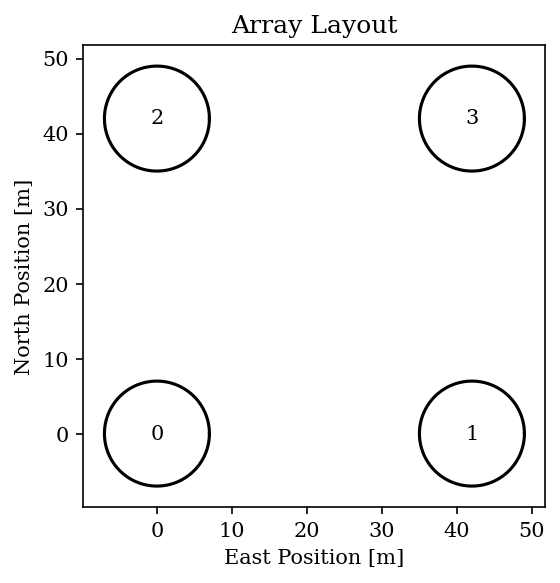

In [7]:
# Next, let's check out where the antennas are placed.
positions, antenna_numbers = uvdata.get_enu_data_ants()
array_layout = dict(zip(antenna_numbers, positions))
# or, for style points: 
# array_layout = dict(zip(*uvdata.get_ENU_antpos()[::-1]))
print(array_layout)
# Now make a plot of the array layout.
plt.figure(figsize=(4,4), dpi=150)
plt.xlabel("East Position [m]")
plt.ylabel("North Position [m]")
plt.title("Array Layout")
    
# This is a neat trick for making it easier to visualize the array.
if uvdata.telescope.antenna_diameters is not None:
    diameter = uvdata.telescope.antenna_diameters[0]
else:
    diameter = 14  # This is the diameter of a HERA antenna, in meters.
dish = 0.5 * diameter * np.exp(1j*np.linspace(0, 2*np.pi, 360))
for ant, (e,n,u) in array_layout.items():
    plt.plot(e+dish.real, n+dish.imag, color='k')
    plt.text(e, n, ant, ha="center", va="center")
    
# Make sure to use a nice aspect ratio.
plt.gca().set_aspect("equal")
plt.savefig("Array_Layout.pdf", bbox_inches="tight")
plt.show()

This is an array consisting of four antennas arranged in a square pattern. We will start by investigating the purely East-West baseline $(0,1)$.

In [8]:
# First, let's retrieve the data for this baseline.
vis = uvdata.get_data(0, 1, "xx")  # We also need to specify which polarization to use. This simulation just has one.

In [9]:
# Now let's look at the array shape and data type.
print(f"The shape of the visibility data for a single baseline is: {vis.shape}")
print(f"The visibility data has type {vis.dtype}")

The shape of the visibility data for a single baseline is: (360, 250)
The visibility data has type complex128


So the visibility data for a single baseline is a 2-dimensional array of 128-bit complex numbers&mdash;just as expected from the earlier discussion! Which axis is the time axis, and which is the frequency axis?

In [10]:
# Let's see how many frequencies and times are in the data.
print(f"There are {uvdata.Nfreqs} frequency channels in this data.")
print(f"There are {uvdata.Ntimes} integrations in this data.")

There are 250 frequency channels in this data.
There are 360 integrations in this data.


That settles it! The rows correspond to different times, and the columns correspond to different frequencies. Let's see what frequencies and times are in the data.

In [11]:
freqs = uvdata.freq_array  # Hz
times, sort = np.unique(uvdata.time_array, return_index=True)  # days
lsts = uvdata.lst_array[sort]  # rad
rad2hr = 12 / np.pi
lsts_hr = lsts * rad2hr
print(f"The observed frequencies span {freqs[0]/1e6:.2f} MHz to {freqs[-1]/1e6:.2f} MHz.")
print(f"The first integration is on Julian Date (JD) {times[0]:.7f}.")
print(f"The last integration is on JD {times[-1]:.7f}.")
print(f"The first observed Local Sidereal Time (LST) is {lsts_hr[0]:.2f} hours.")
print(f"The last observed LST is {lsts_hr[-1]:.2f} hours.")

The observed frequencies span 100.00 MHz to 349.00 MHz.
The first integration is on Julian Date (JD) 2458116.4763346.
The last integration is on JD 2458116.5594364.
The first observed Local Sidereal Time (LST) is 7.37 hours.
The last observed LST is 9.37 hours.


Now we've got everything we need to start plotting. We'll start with some line plots, looking at how the visibility evolves in both frequency and time.

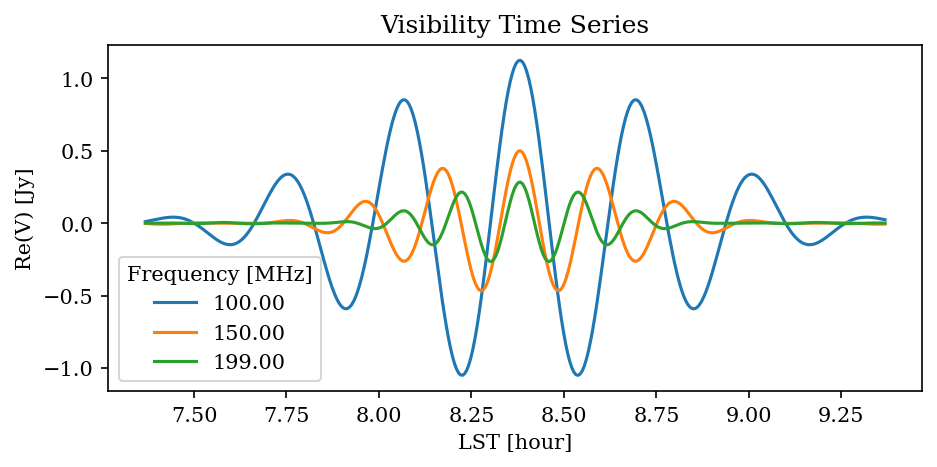

In [12]:
plt.figure(figsize=(7,3), dpi=150)
plt.xlabel("LST [hour]")
plt.ylabel(r"Re(V) [Jy]")
plt.title("Visibility Time Series")
for chan in (0, 50, 99):
    freq_MHz = freqs[chan] / 1e6
    plt.plot(lsts_hr, vis[:,chan].real, label=f"{freq_MHz:.2f}")
plt.legend(title="Frequency [MHz]")
plt.savefig("Visibility_time_series.pdf", bbox_inches="tight")
plt.show()

So, as a function of time, the real part of the visibility oscillates, and the amplitude is modulated. The amplitude and oscillation period clearly depends on frequency, and the oscillation period also (subtly) varies with time.  
  
<b>Question: Why does the visibility amplitude change with time?</b>  
<b>Question: Why does the oscillation period change with frequency?</b>  
<b>Question: Why does the real part of the visibility oscillate?</b>

As an exercise, try plotting the absolute value of the visibility, the imaginary part, and the phase. <b>Explain what you see in each of the plots.</b>

In [ ]:
"""Question: Why does the visibility amplitude change with time?
the visibility amplitude varies with LST because Earth’s rotation continuously changes the sky region being observed, modulating the weighted integral of sky brightness within the beam.
Question: Why does the oscillation period change with frequency?
Question: Why does the real part of the visibility oscillate?

As an exercise, try plotting the absolute value of the visibility, the imaginary part, and the phase. Explain what you see in each of the plots.
"""

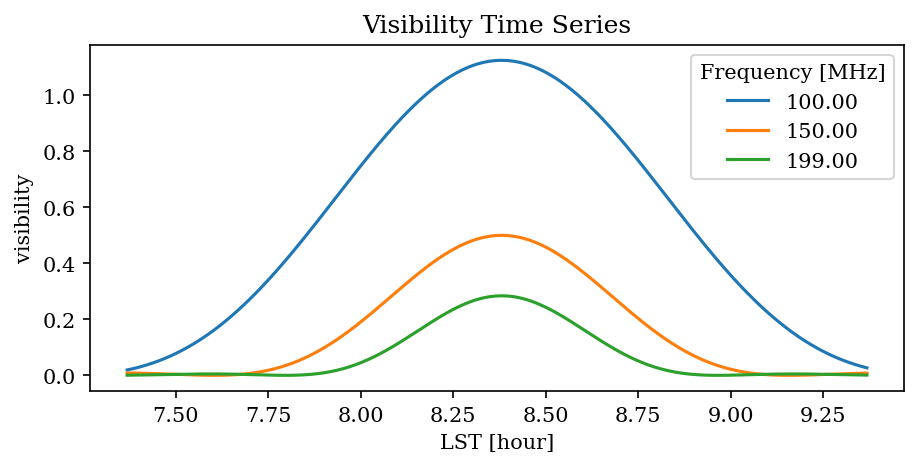

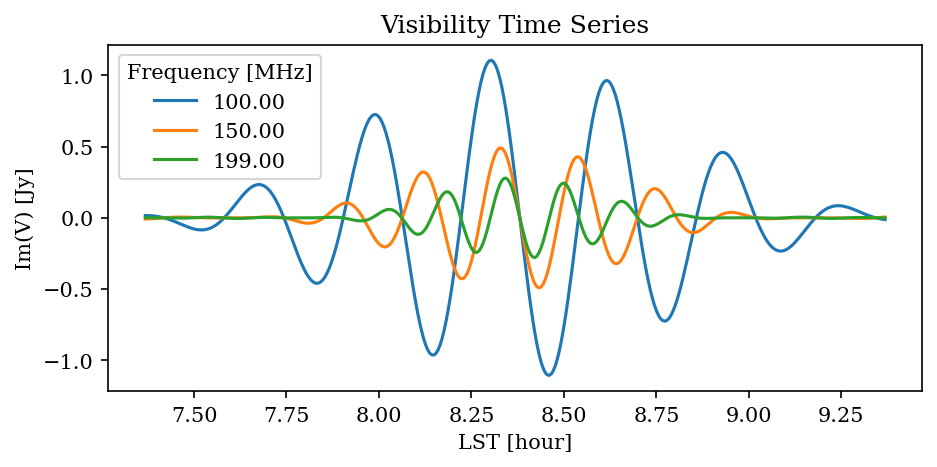

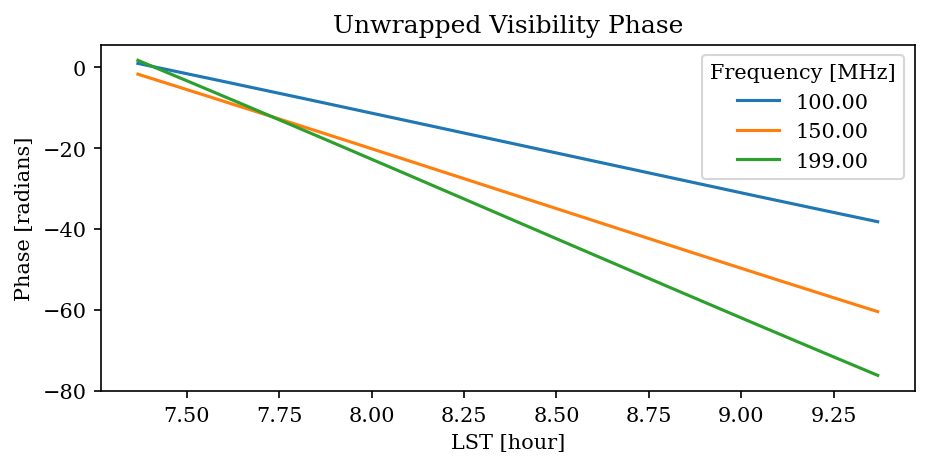

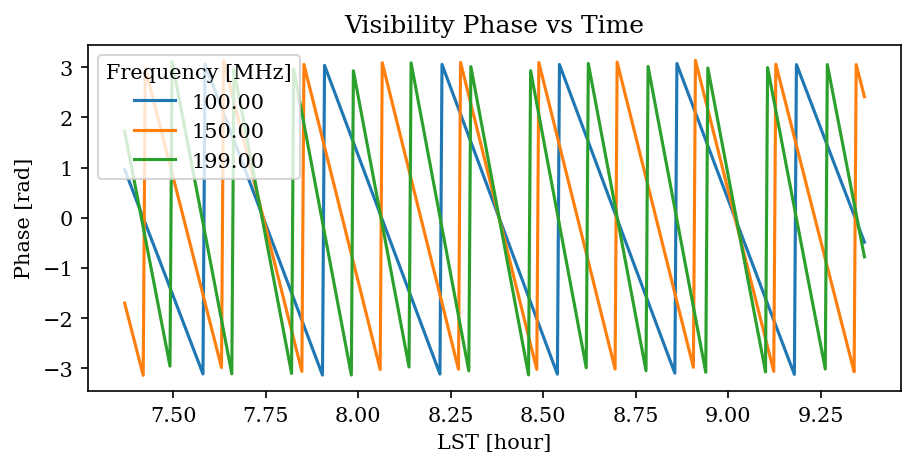

In [23]:
# your code here
#absolute value of the visibility
plt.figure(figsize=(7,3), dpi=150)
plt.xlabel("LST [hour]")
plt.ylabel(r"visibility")
plt.title("Visibility Time Series")
for chan in (0, 50, 99):
    freq_MHz = freqs[chan] / 1e6
    plt.plot(lsts_hr, abs(vis[:,chan]), label=f"{freq_MHz:.2f}")
plt.legend(title="Frequency [MHz]")
plt.savefig("absolute_value_visibility.pdf", bbox_inches="tight")
plt.show()
#imaginary part
plt.figure(figsize=(7,3), dpi=150)
plt.xlabel("LST [hour]")
plt.ylabel(r"Im(V) [Jy]")
plt.title("Visibility Time Series")
for chan in (0, 50, 99):
    freq_MHz = freqs[chan] / 1e6
    plt.plot(lsts_hr, vis[:,chan].imag, label=f"{freq_MHz:.2f}")
plt.legend(title="Frequency [MHz]")
plt.savefig("Imaginary_visibility.pdf", bbox_inches="tight")
plt.show()
#phase
plt.figure(figsize=(7,3), dpi=150)
plt.xlabel("LST [hour]")
plt.ylabel("Phase [radians]")
plt.title("Unwrapped Visibility Phase")
for chan in (0, 50, 99):
    freq_MHz = freqs[chan] / 1e6
    phase = np.unwrap(np.angle(vis[:, chan]))
    plt.plot(lsts_hr, phase, label=f"{freq_MHz:.2f}")
plt.legend(title="Frequency [MHz]")
plt.savefig("Visibility_phase.pdf", bbox_inches="tight")
plt.show()
#Phase
plt.figure(figsize=(7,3), dpi=150)
plt.xlabel("LST [hour]")
plt.ylabel("Phase [rad]")
plt.title("Visibility Phase vs Time")
for chan in (0, 50, 99):
    freq_MHz = freqs[chan] / 1e6
    phase = np.angle(vis[:, chan])
    plt.plot(lsts_hr, phase, label=f"{freq_MHz:.2f}")
plt.legend(title="Frequency [MHz]")
plt.savefig("Visibility_phase_vs_time.pdf",bbox_inches="tight")
plt.show()

Now, let's look at the visibility as a function of frequency at a few fixed times.

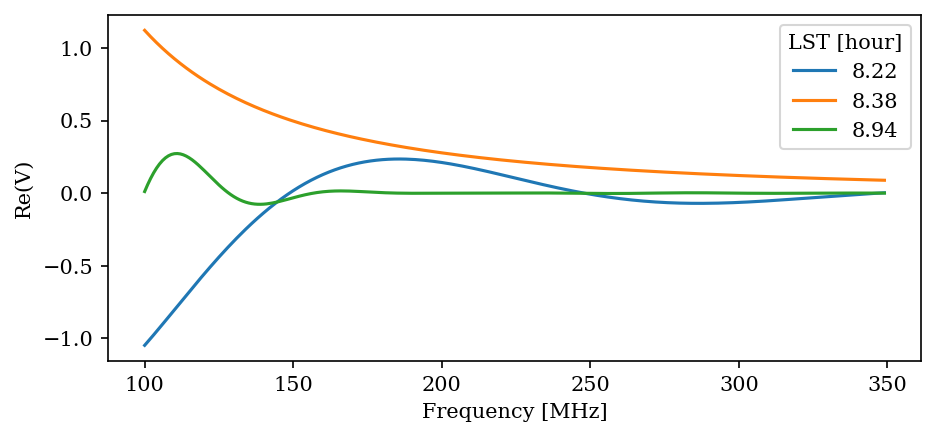

In [14]:
freqs_MHz = freqs / 1e6
plt.figure(figsize=(7,3), dpi=150)
plt.xlabel("Frequency [MHz]")
plt.ylabel("Re(V)")

for i in (153, 181, 282):
    plt.plot(freqs_MHz, vis[i].real, label=f"{lsts_hr[i]:.2f}")
    
plt.legend(title="LST [hour]")
plt.savefig("Vis_Real_Frequency.pdf", bbox_inches="tight")
plt.show()

Does this look like what you expect? See if you can find the places on the time-series plot that correspond to the integrations plotted here. Where in the beam is the source sitting at each of these integrations? Does that help explain what's going on here?

In [ ]:
"""Does this look like what you expect? 
See if you can find the places on the time-series plot that correspond to the integrations plotted here. 
Where in the beam is the source sitting at each of these integrations? Does that help explain what's going on here?"""

Just like with the previous section, try plotting the absolute value, imaginary part, and phase of the visibility as a function of frequency.

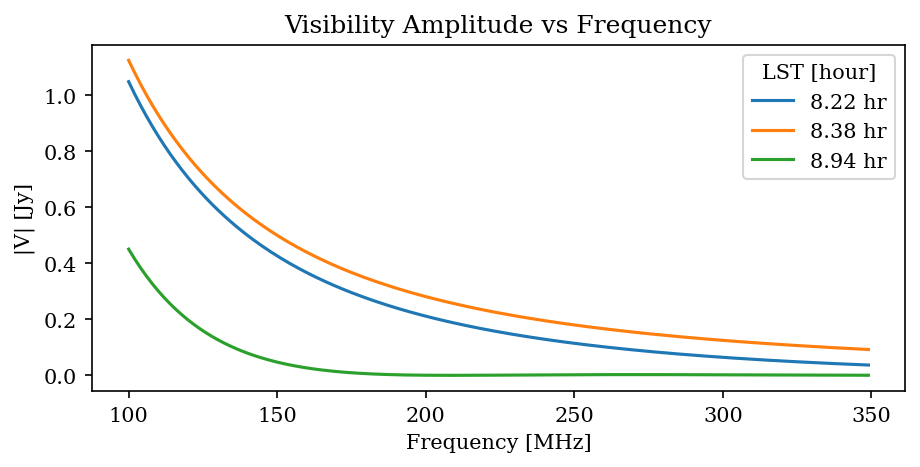

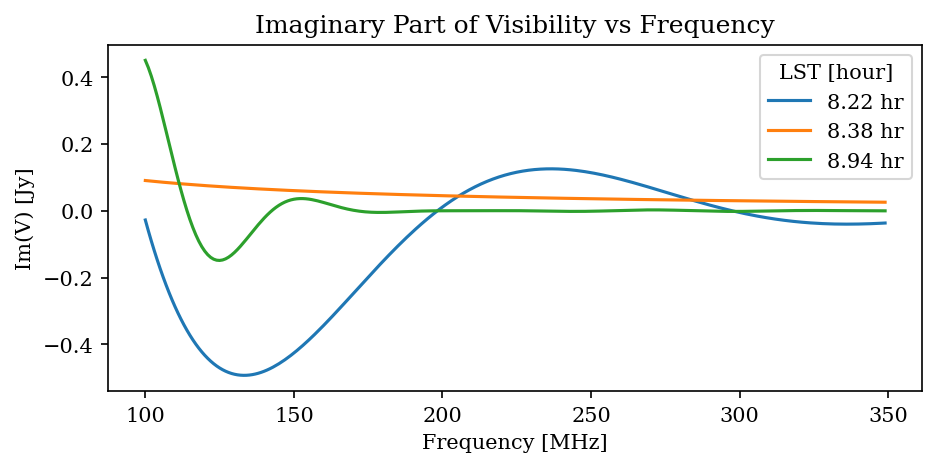

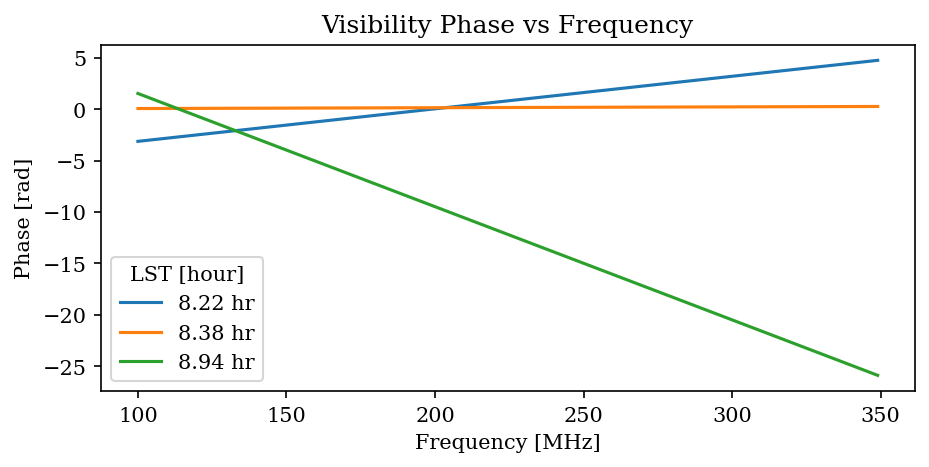

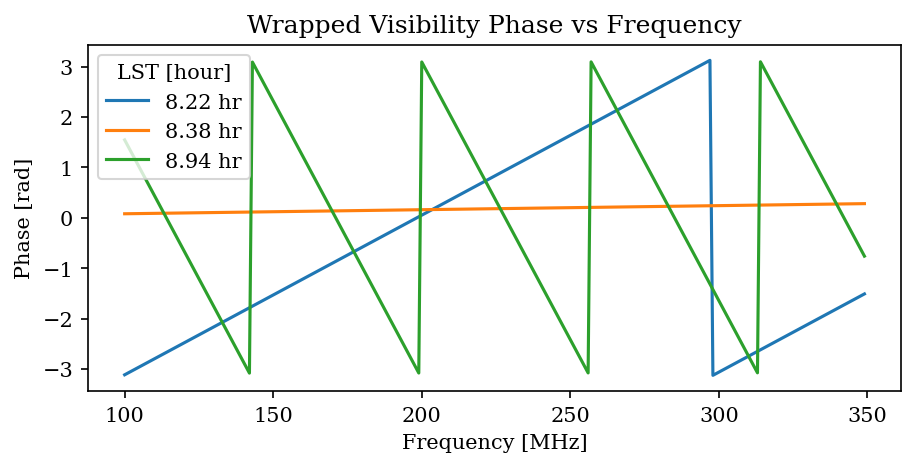

In [35]:
# your code here
#absolute value
freqs_MHz = freqs / 1e6
plt.figure(figsize=(7,3), dpi=150)
plt.xlabel("Frequency [MHz]")
plt.ylabel(r"|V| [Jy]")
plt.title("Visibility Amplitude vs Frequency")
for i in (153, 181, 282):
    plt.plot(freqs_MHz, np.abs(vis[i]), label=f"{lsts_hr[i]:.2f} hr")
plt.legend(title="LST [hour]")
plt.savefig("Vis_Amplitude_Frequency.pdf", bbox_inches="tight")
plt.show()
#imaginary part
plt.figure(figsize=(7,3), dpi=150)
plt.xlabel("Frequency [MHz]")
plt.ylabel(r"Im(V) [Jy]")
plt.title("Imaginary Part of Visibility vs Frequency")
for i in (153, 181, 282):
    plt.plot(freqs_MHz, vis[i].imag, label=f"{lsts_hr[i]:.2f} hr")
plt.legend(title="LST [hour]")
plt.savefig("Vis_Imag_Frequency.pdf", bbox_inches="tight")
plt.show()
#phase of the visibility as a funciton of frequency
plt.figure(figsize=(7,3), dpi=150)
plt.xlabel("Frequency [MHz]")
plt.ylabel("Phase [rad]")
plt.title("Visibility Phase vs Frequency")
for i in (153, 181, 282):
    plt.plot(freqs_MHz, np.unwrap(np.angle(vis[i])), label=f"{lsts_hr[i]:.2f} hr")
plt.legend(title="LST [hour]")
plt.savefig("Vis_Phase_Frequency.pdf", bbox_inches="tight")
plt.show()
# wrapped phase of visibility vs frequency
plt.figure(figsize=(7,3), dpi=150)
plt.xlabel("Frequency [MHz]")
plt.ylabel("Phase [rad]")
plt.title("Wrapped Visibility Phase vs Frequency")
for i in (153, 181, 282):
    plt.plot(freqs_MHz, np.angle(vis[i]), label=f"{lsts_hr[i]:.2f} hr")
plt.legend(title="LST [hour]")
plt.savefig("Vis_Phase_Frequency_Wrapped.pdf", bbox_inches="tight")
plt.show()

While these line plots can be useful for getting a sense of what's in the data, they're incredibly inefficient for visualizing all of the data we have&mdash;these plots only show a few percent of all the data in this small simulation! In order to maximize the amount of information conveyed in a single plot, we often make <i>waterfall plots</i> of the data, where we look at some aspect of the visibility (usually amplitude or phase) as a function of frequency and time simultaneously. Here's an example of how to make a waterfall plot:

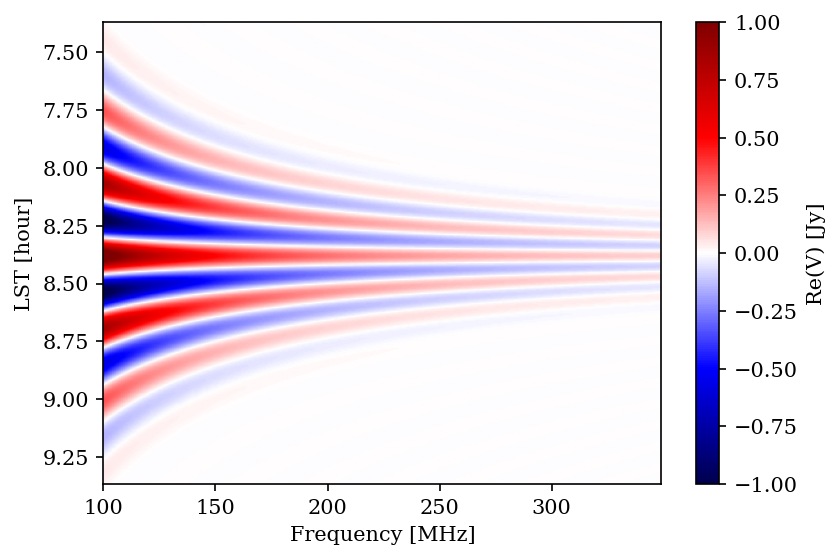

In [29]:
extent = (freqs_MHz[0], freqs_MHz[-1], lsts_hr[-1], lsts_hr[0])
plt.figure(figsize=(6,4), dpi=150)
plt.xlabel("Frequency [MHz]")
plt.ylabel("LST [hour]")
plt.imshow(np.real(vis), extent=extent, aspect='auto', cmap="seismic", vmin=-1, vmax=1)
plt.colorbar(label="Re(V) [Jy]")
plt.savefig("Waterfall_ReV.pdf", bbox_inches="tight")
plt.show()

This is a <i>waterfall</i> of the real part of the visibility, where the start of observing is at the top of the plot, the end of observing is at the bottom, and the full range of frequencies goes along the horizontal axis. This type of plot can contain a huge amount of information, and a trained eye can learn various things about the instrument and the sky just by glancing at a plot like this.  
  
<b>Make your own waterfalls that look at the amplitude, phase, and imaginary part of the visibility. Try to choose colormaps and colorbar normalizations that enhance the ability to read off information from the plots.</b>

In [ ]:
"""Make your own waterfalls that look at the amplitude, phase, and imaginary part of the visibility."""

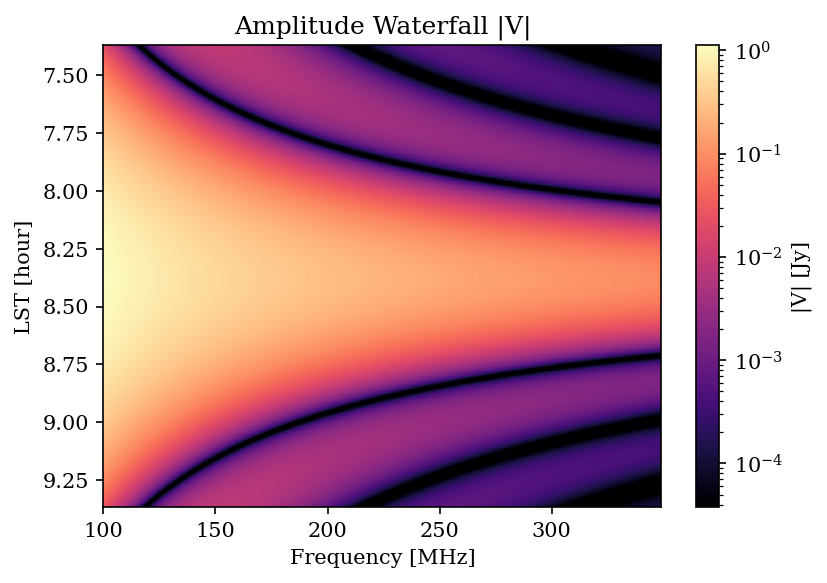

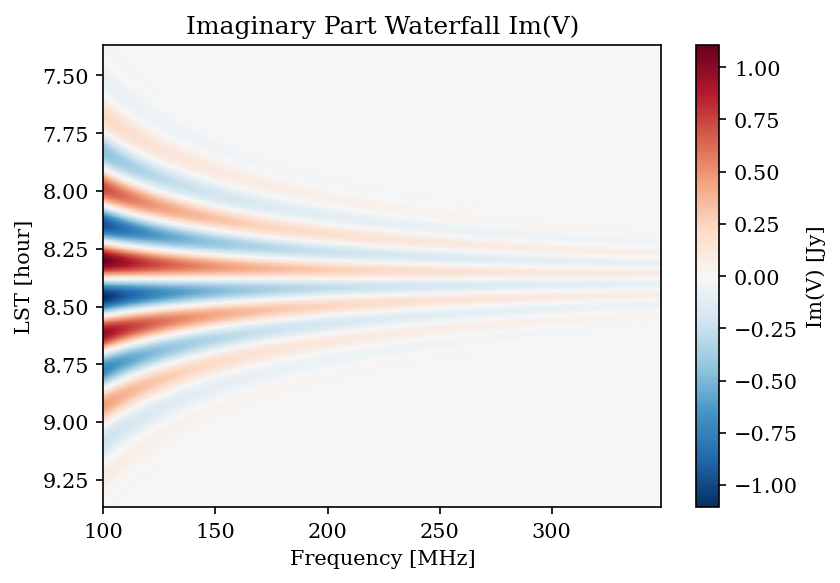

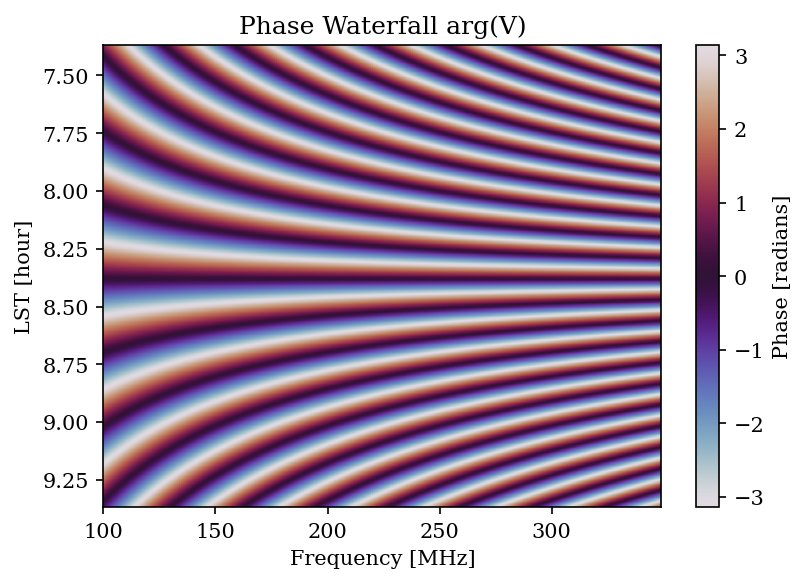

In [28]:
# your code here important!
extent = (freqs_MHz[0], freqs_MHz[-1], lsts_hr[-1], lsts_hr[0])
# Amplitude Waterfall |V|
plt.figure(figsize=(6,4), dpi=150)
plt.xlabel("Frequency [MHz]")
plt.ylabel("LST [hour]")
plt.title("Amplitude Waterfall |V|")
plt.imshow(np.abs(vis),aspect="auto",extent=extent,cmap="magma",norm=plt.cm.colors.LogNorm(vmin=np.percentile(np.abs(vis), 5),vmax=np.max(np.abs(vis))))
plt.colorbar(label="|V| [Jy]")
plt.savefig("Waterfall_Amplitude.pdf", bbox_inches="tight")
plt.show()
# Imaginary Part Waterfall
plt.figure(figsize=(6,4), dpi=150)
plt.xlabel("Frequency [MHz]")
plt.ylabel("LST [hour]")
plt.title("Imaginary Part Waterfall Im(V)")
vmax = np.max(np.abs(np.imag(vis)))
plt.imshow(np.imag(vis),aspect="auto",extent=extent,cmap="RdBu_r",vmin=-vmax,vmax=vmax)
plt.colorbar(label="Im(V) [Jy]")
plt.savefig("Waterfall_Imaginary.pdf", bbox_inches="tight")
plt.show()
# Phase Waterfall arg(V)
plt.figure(figsize=(6,4), dpi=150)
plt.xlabel("Frequency [MHz]")
plt.ylabel("LST [hour]")
plt.title("Phase Waterfall arg(V)")
plt.imshow(np.angle(vis),aspect="auto",extent=extent,cmap="twilight",vmin=-np.pi,vmax=np.pi)
plt.colorbar(label="Phase [radians]")
plt.savefig("Waterfall_Phase.pdf", bbox_inches="tight")
plt.show()

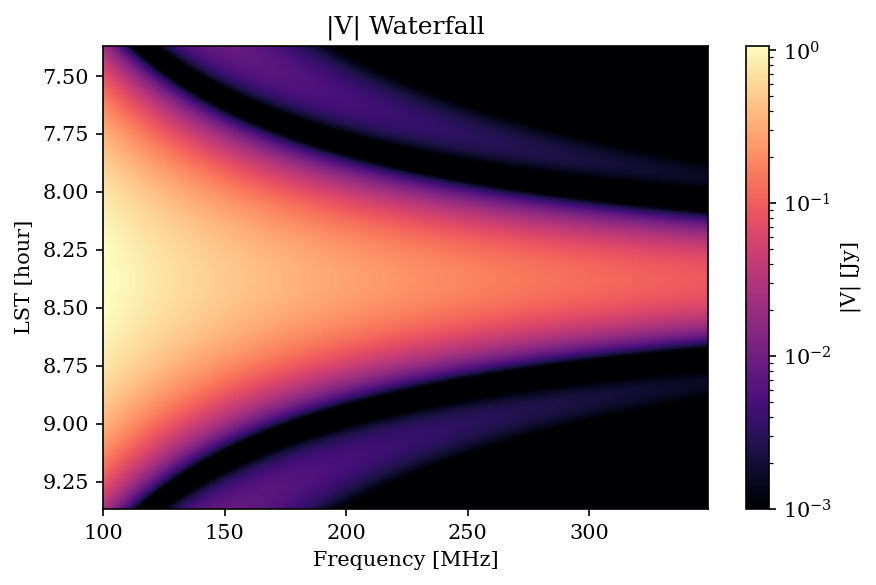

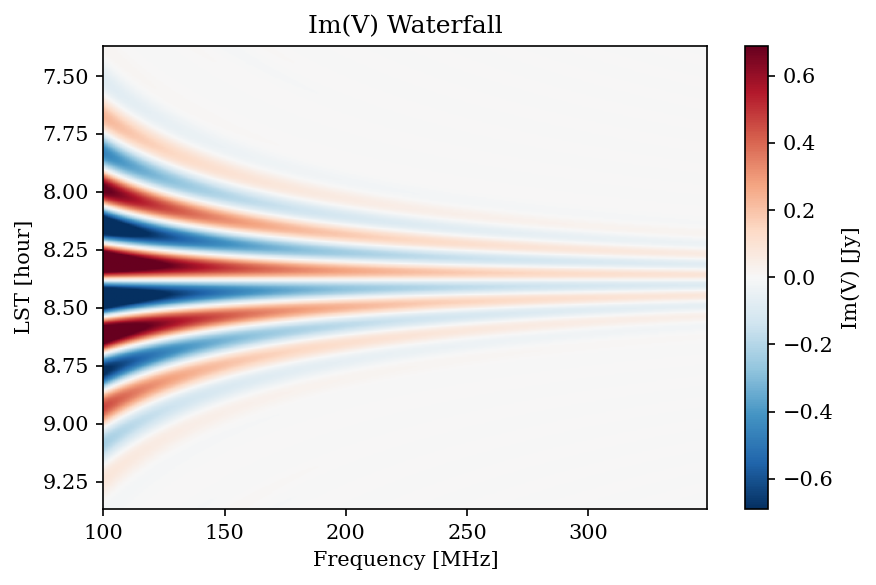

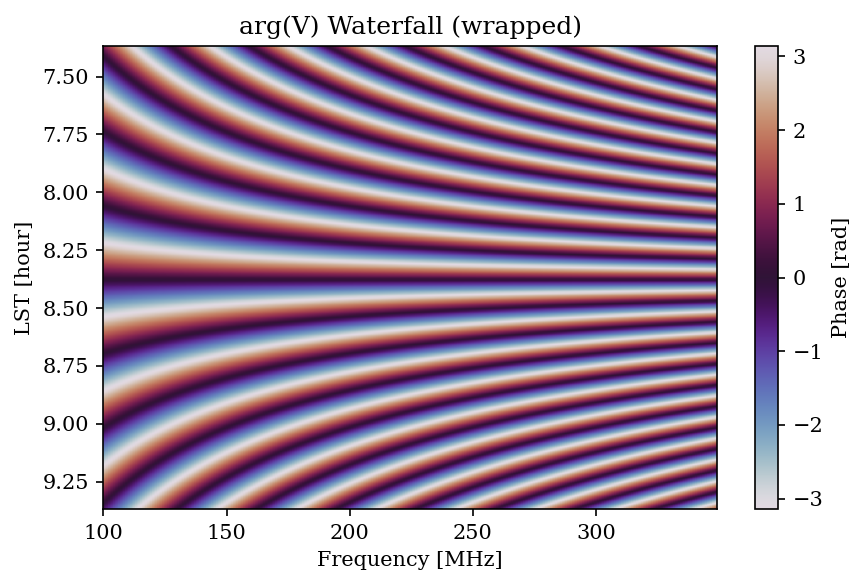

In [38]:
# your code here important!
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
freqs_MHz = freqs / 1e6
extent = (freqs_MHz[0], freqs_MHz[-1], lsts_hr[-1], lsts_hr[0])  # time increases downward
# 1) Amplitude waterfall (log scale is most readable across dynamic range)
amp = np.abs(vis)
vmin = max(1e-3, np.percentile(amp, 5))  
vmax = np.percentile(amp, 99.9)           
plt.figure(figsize=(6,4), dpi=150)
plt.xlabel("Frequency [MHz]")
plt.ylabel("LST [hour]")
plt.title("|V| Waterfall")
plt.imshow(amp, aspect="auto", extent=extent, cmap="magma",
           norm=LogNorm(vmin=vmin, vmax=vmax))
plt.colorbar(label="|V| [Jy]")
plt.tight_layout()
plt.savefig("Waterfall_Amplitude.pdf", bbox_inches="tight")
plt.show()

# 2) Imaginary part waterfall (diverging colormap, symmetric limits)
imag = vis.imag
vmax = np.percentile(np.abs(imag), 99)
plt.figure(figsize=(6,4), dpi=150)
plt.xlabel("Frequency [MHz]")
plt.ylabel("LST [hour]")
plt.title("Im(V) Waterfall")
plt.imshow(imag, aspect="auto", extent=extent, cmap="RdBu_r",vmin=-vmax, vmax=vmax)
plt.colorbar(label="Im(V) [Jy]")
plt.tight_layout()
plt.savefig("Waterfall_Imag.pdf", bbox_inches="tight")
plt.show()
# 3) Phase waterfall (wrapped to [-pi, pi])
freqs_MHz = freqs / 1e6
extent = (freqs_MHz[0], freqs_MHz[-1], lsts_hr[-1], lsts_hr[0]) 
phase = np.angle(vis)
plt.figure(figsize=(6,4), dpi=150)
plt.xlabel("Frequency [MHz]")
plt.ylabel("LST [hour]")
plt.title("arg(V) Waterfall (wrapped)")
plt.imshow(phase,aspect="auto",extent=extent,cmap="twilight",vmin=-np.pi,vmax=np.pi,)
plt.colorbar(label="Phase [rad]")
plt.tight_layout()
plt.savefig("Waterfall_Phase_Wrapped.pdf", bbox_inches="tight")
plt.show()

So far we've looked at the visibility as a function of frequency and time. What happens if we Fourier transform along either of these axes? Let's go back to some line plots to investigate.

The <i>fringe-rate transform</i> is the Fourier transform of the visibility along the time axis: when we Fourier transform the visibility along the time axis, we are investigating how the visibility behaves as a function of <i>fringe-rate</i>. This terminology carries some physical significance: it roughly corresponds to how rapidly sources on the sky are moving through the baseline's fringe-pattern. It turns out that there is a good amount of geometric intuition that comes with thinking in this space, but that's a skill we'll develop later. (If you have some free time and are interested in trying to learn some of the basics, then I would recommend starting with [this paper](https://iopscience.iop.org/article/10.3847/0004-637X/820/1/51) or [this paper](https://iopscience.iop.org/article/10.3847/1538-4357/adc37d), but this is a pretty advanced topic.)

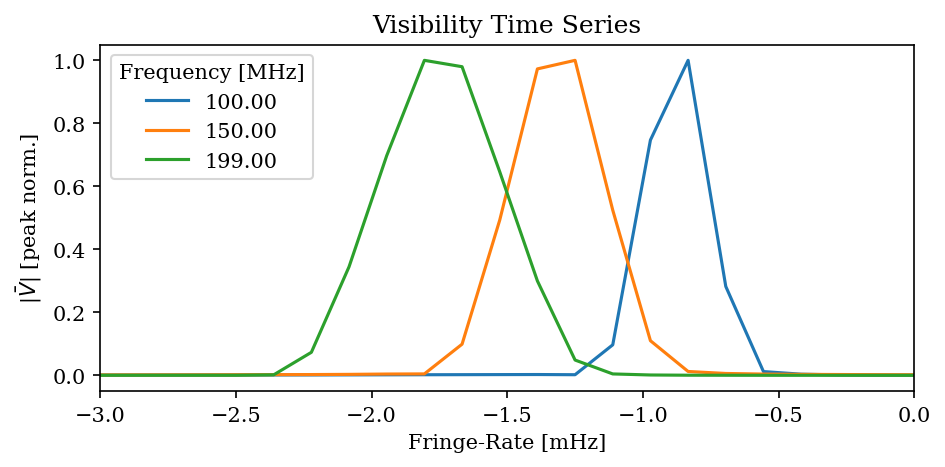

In [19]:
# Let's figure out which fringe-rates we're sensitive to.
integration_time = uvdata.integration_time[0]  # seconds
fringe_rates = np.fft.fftshift(
    np.fft.fftfreq(uvdata.Ntimes, integration_time)
) * 1e3  # mHz

# Now let's see what the fringe-rate transform looks like at a few frequencies.
plt.figure(figsize=(7,3), dpi=150)
plt.xlabel("Fringe-Rate [mHz]")
plt.ylabel(r"|$\bar{V}$| [peak norm.]")
plt.title("Visibility Time Series")
for chan in (0, 50, 99):
    freq_MHz = freqs[chan] / 1e6
    plot_data = np.fft.fftshift(
        np.fft.fft(np.fft.ifftshift(vis[:,chan]))
    )
    plt.plot(fringe_rates, np.abs(plot_data)/np.abs(plot_data).max(), label=f"{freq_MHz:.2f}")
    
plt.xlim(-3, 0)
plt.legend(title="Frequency [MHz]")
plt.show()

This might look a little weird, but it is consistent with the notion that the fringe-rate transform provides information about how stuff on the sky is moving through the fringe pattern. At higher frequencies, the fringe period is shorter, so sources effectively move through the fringe faster.  
  
<b>Question: What is causing the sources to "move" through the fringe? Does this help explain why power is distributed in fringe-rate differently for different frequencies?</b>

In [ ]:
"""Question: What is causing the sources to "move" through the fringe? 
Does this help explain why power is distributed in fringe-rate differently for different frequencies?"""

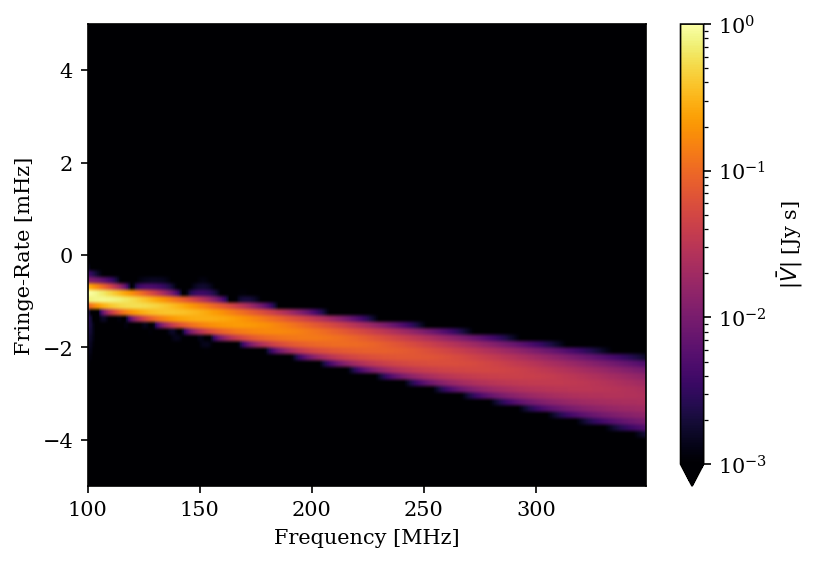

In [20]:
# Now let's look at a fringe-rate vs frequency waterfall.
extent = (freqs_MHz[0], freqs_MHz[-1], fringe_rates[-1], fringe_rates[0])
plot_data = np.fft.fftshift(
    np.fft.fft(np.fft.ifftshift(vis, axes=0), axis=0), axes=0
)

# Peak normalize the data
plot_data = np.abs(plot_data) / np.abs(plot_data).max()

# This is some colorbar configuration stuff. Do not blindly copy-paste this!
vmax = 1
vmin = 1e-3
norm = plt.cm.colors.LogNorm(vmin=vmin, vmax=vmax)

# Actually make the plot.
plt.figure(figsize=(6,4), dpi=150)
plt.xlabel("Frequency [MHz]")
plt.ylabel("Fringe-Rate [mHz]")
plt.imshow(plot_data, cmap="inferno", aspect="auto", extent=extent, norm=norm)
plt.ylim(-5, 5)
plt.colorbar(label=r"$|\bar{V}|$ [Jy s]", extend="min")
plt.show()

This plot is probably quite a bit more difficult to interpret than the first waterfall plot, but there is also a lot of information that can be retrieved from staring at this. The two main things that can be read off of this plot are the East-West projected baseline length, and roughly where on the sky the bulk of the emission is coming from over the full observation period.  
  
<b>Question: The slope of this bright strip (i.e., the fringe-rate at which the visibility is peaked as a function of frequency) is related to the East-West baseline length. How do you think the slope will change as we increase/decrease the East-West baseline length?</b>  

Instead of taking the Fourier transform along the time axis, we can take it along the frequency axis. We refer to this as taking the <i>delay transform</i> of the data. Let's investigate.

In [ ]:
"""Question: The slope of this bright strip (i.e., the fringe-rate at which the visibility is peaked as a function of frequency) is related to the East-West baseline length. 
How do you think the slope will change as we increase/decrease the East-West baseline length?"""

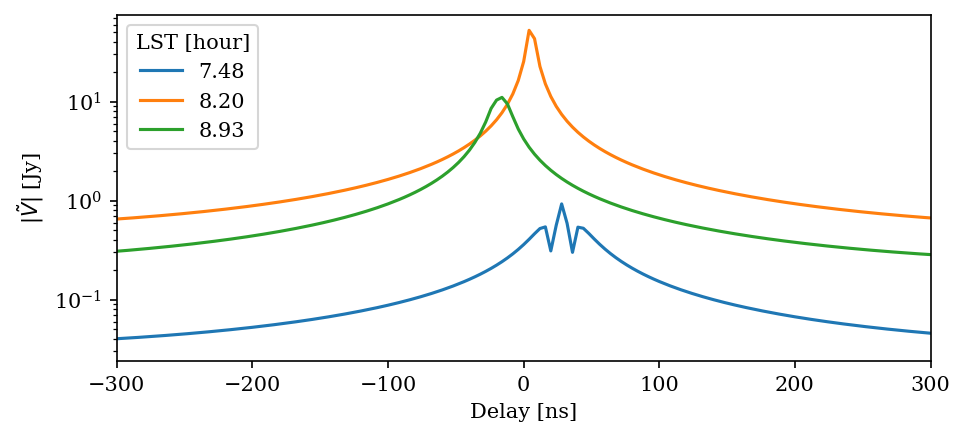

In [21]:
channel_width = uvdata.channel_width[0]  # Hz
delays = np.fft.fftshift(
    np.fft.fftfreq(uvdata.Nfreqs, channel_width)
) * 1e9  # ns

plt.figure(figsize=(7,3), dpi=150)
plt.xlabel("Delay [ns]")
plt.ylabel(r"$|\tilde{V}|$ [Jy]")

plot_data = np.fft.fftshift(
    np.fft.fft(np.fft.ifftshift(vis, axes=1), axis=1), axes=1
)
for i in (20, 150, 280):
    plt.semilogy(delays, np.abs(plot_data[i]), label=f"{lsts_hr[i]:.2f}")
    
plt.xlim(-300, 300)
plt.legend(title="LST [hour]", loc="upper left")
plt.show()

This may also be a bit confusing&mdash;the peaks move around, the amplitude changes substantially between the curves, and there are these huge tails! The tails are a consequence of the data not being periodic as a function of frequency, so the sinc sidelobes are throwing out the foreground power to a wide range of delays (think back to the convolution theorem to try to make sense of this statement). The locations of the peaks are a direct consequence of the geometry of the observations, and the amplitude has to do with where the source is sitting in the beam.  
  
<b>Question: Draw a 1-dimensional pictue of the observing setup. The antennas are pointing straight up, and the source is at zenith (i.e., directly above the antennas) for the orange curve. Draw the source position at the three different observing times and think about the <i>geometric delay</i> that the baseline will measure at each time. How does that compare to the locations of the peaks?</b>  
  
<b>Question: The simulation used an Airy beam for the antenna response. Where are the first nulls in an Airy disk (you can find this on Wikipedia)? How far has the source moved away from zenith for the blue and the green curves? Does this explain the difference in the amplitudes?</b>

In [ ]:
"""Question: Draw a 1-dimensional pictue of the observing setup. 
The antennas are pointing straight up, and the source is at zenith (i.e., directly above the antennas) for the orange curve. 
Draw the source position at the three different observing times and think about the geometric delay that the baseline will measure at each time. 
How does that compare to the locations of the peaks?

Question: The simulation used an Airy beam for the antenna response. 
Where are the first nulls in an Airy disk (you can find this on Wikipedia)? 
How far has the source moved away from zenith for the blue and the green curves? Does this explain the difference in the amplitudes?"""

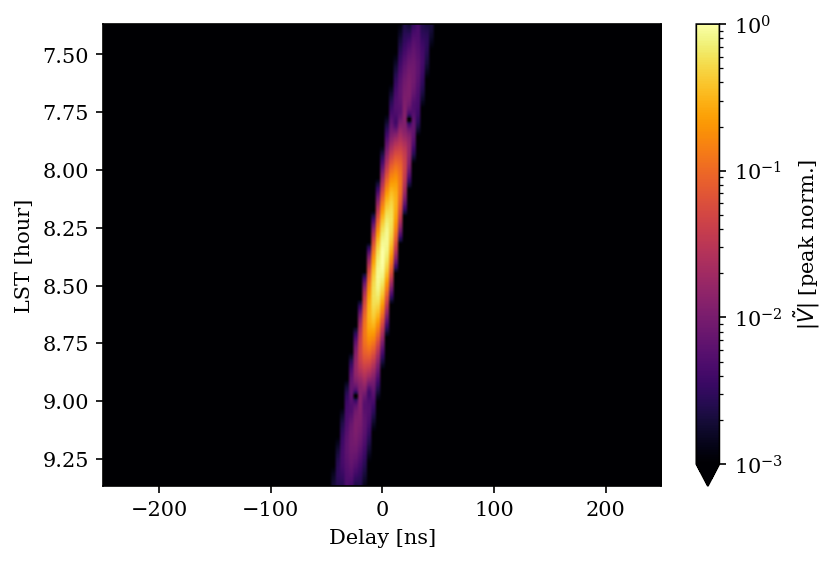

In [22]:
# Now let's look at a time-delay waterfall
extent = (delays[0], delays[-1], lsts_hr[-1], lsts_hr[0])

# It's a bit difficult to interpret the figure without this bit of code.
# This tapering technique is useful for mitigating Fourier sidelobes,
# but a thorough discussion of it will take some time. For now, just treat
# it as a bit of magic that makes the plot look nice.
taper = uvtools.dspec.gen_window("bh", uvdata.Nfreqs)
plot_data = np.fft.fftshift(
    np.fft.fft(np.fft.ifftshift(taper[None,:] * vis, axes=1), axis=1), axes=1
)

# Peak-normalize the data for visualization purposes
plot_data = np.abs(plot_data) / np.abs(plot_data).max()

# More colorbar configuration stuff.
vmax = 1
vmin = 1e-3
norm = plt.cm.colors.LogNorm(vmin=vmin, vmax=vmax)

# Actually make the plot.
plt.figure(figsize=(6,4), dpi=150)
plt.xlabel("Delay [ns]")
plt.ylabel("LST [hour]")
plt.imshow(np.abs(plot_data), extent=extent, aspect='auto', cmap='inferno', norm=norm)
plt.xlim(-250, 250)

plt.colorbar(label=r"$|\tilde{V}|$ [peak norm.]", extend="min")
plt.show()

This is also a very useful space for visualizing visibility data. Here you can clearly see the source transiting the beam. (These sorts of plots are really cool to look at for real data or more realistic simulations&mdash;you can see when sources rise and set!)  
  
<b>Question: What is the horizon delay for this baseline? Plot it as vertical lines on the above plot.</b>

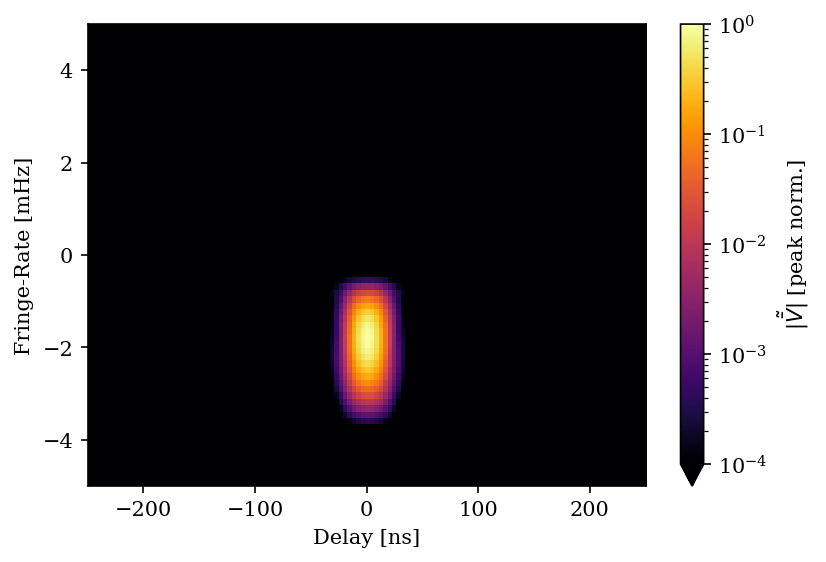

In [23]:
# We can also Fourier transform along both axes!
# This gives us a fringe-rate vs delay waterfall
freq_taper = uvtools.dspec.gen_window("bh", uvdata.Nfreqs)[np.newaxis, :]
time_taper = uvtools.dspec.gen_window("bh", uvdata.Ntimes)[:, np.newaxis]
plot_data = np.fft.fftshift(
    np.fft.fft2(np.fft.ifftshift(freq_taper * time_taper * vis))
)

# Peak normalize the data to simplify visualization
plot_data = np.abs(plot_data) / np.abs(plot_data).max()

# Configure stuff for the plot.
extent = (delays[0], delays[-1], fringe_rates[-1], fringe_rates[0])
vmax = 1
vmin = 1e-4
norm = plt.cm.colors.LogNorm(vmin=vmin, vmax=vmax)

plt.figure(figsize=(6,4), dpi=150)
plt.xlabel("Delay [ns]")
plt.ylabel("Fringe-Rate [mHz]")
plt.imshow(np.abs(plot_data), cmap='inferno', aspect='auto', extent=extent, norm=norm)
plt.xlim(-250, 250)
plt.ylim(-5, 5)
plt.colorbar(label=r"$|\tilde{\bar{V}}|$ [peak norm.]", extend="min")
plt.show()

This is perhaps the most useful space for plotting visibilities, at least in the context of teasing out systematics in the data. Emission from the sky is confined to a small region of this space, and emission in the main lobe of the beam is confined to an even smaller region (which is the blob shown above). At this point, we haven't dug quite deeply enough into the theory for these statements to make sense, but it's useful to start looking at these sorts of plots.

Now, doing all these Fourier transforms by hand can be a bit tedious. I wrote some plotting code and put it in `uvtools` to help with making these. Here's a quick example showing how to make a single waterfall, as well as a four-panel figure showing the various Fourier transforms.

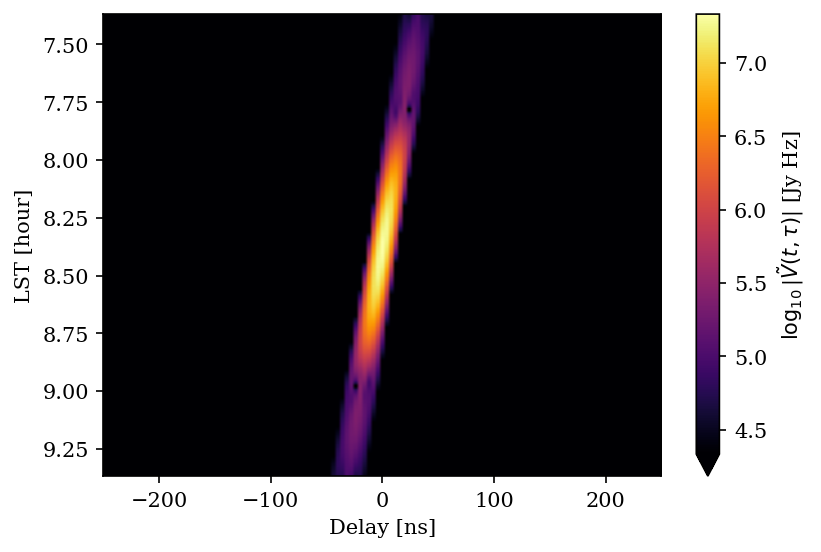

In [24]:
fig, ax = uvtools.plot.labeled_waterfall(
    data=uvdata,
    antpairpol=(0,1,'xx'),
    dynamic_range=3,  # Number of orders-of-magnitude to include in the colorscale
    figsize=(6,4),
    dpi=150,
    fft_axis="freq",
    freq_taper="bh",
    set_title=False,
)
ax.set_xlim(-250, 250)
plt.show()

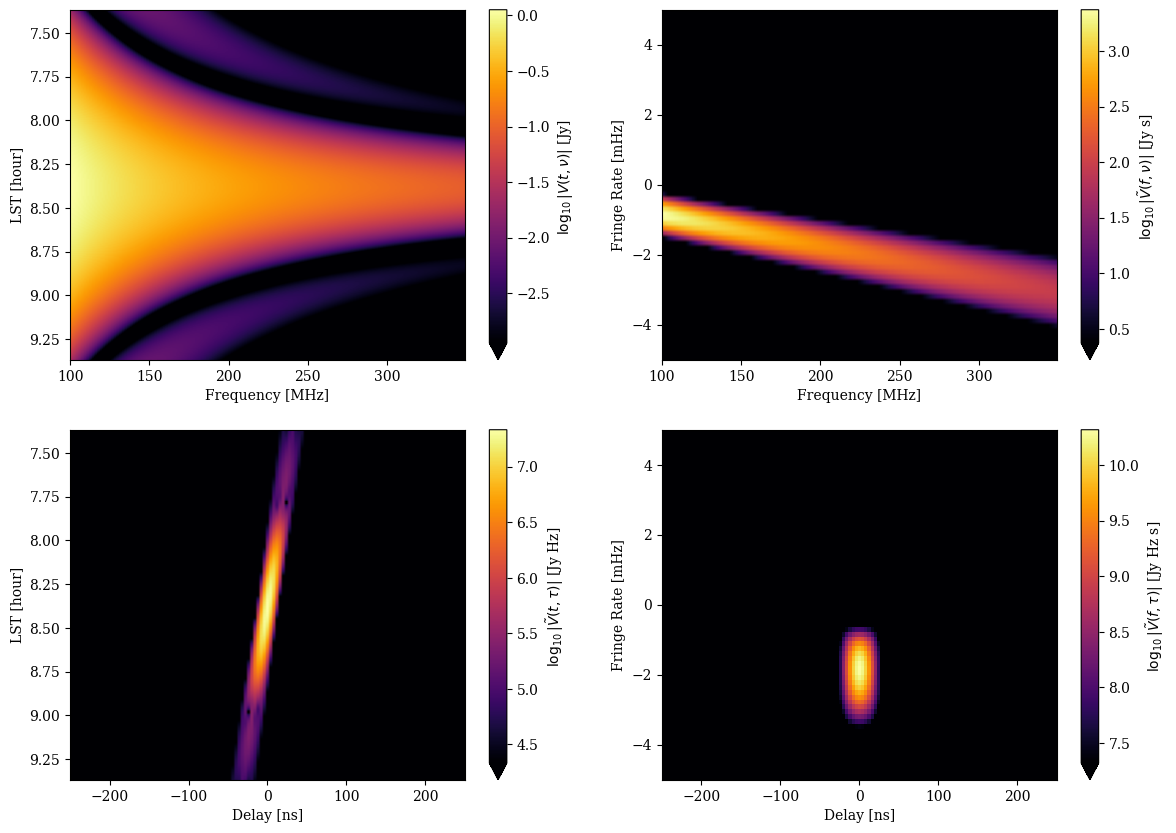

In [25]:
fig = uvtools.plot.fourier_transform_waterfalls(
    data=uvdata,
    antpairpol=(0,1,'xx'),
    freq_taper="bh",
    time_taper="bh",
    plot_limits={"fringe-rate": (-5, 5), "delay": (-250,250)},
    dynamic_range={"fringe-rate": 3, "delay": 3, "freq": 3},
    set_title=False,
)
plt.show()

<b>Now remake all of the above plots for the other baselines in the array. Take note of how the visibilities look in these various spaces as a function of baseline length and orientation.</b>


Baseline (0,1) = 42.00 m


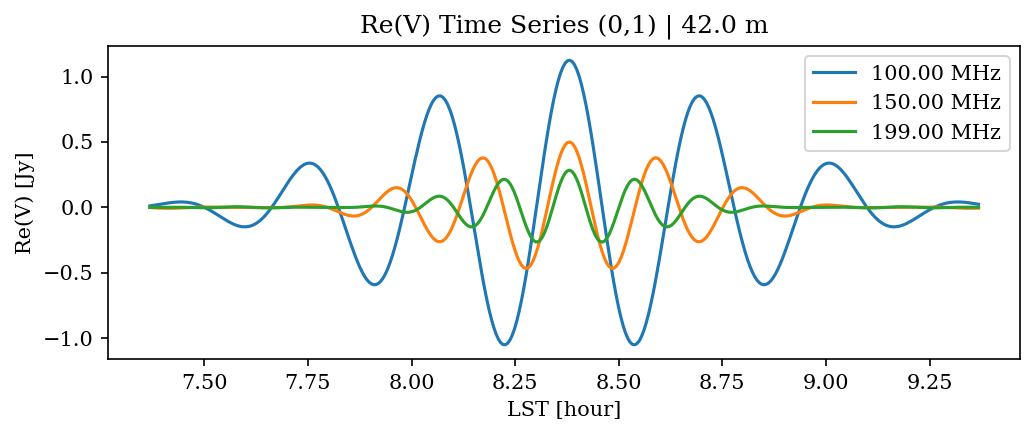

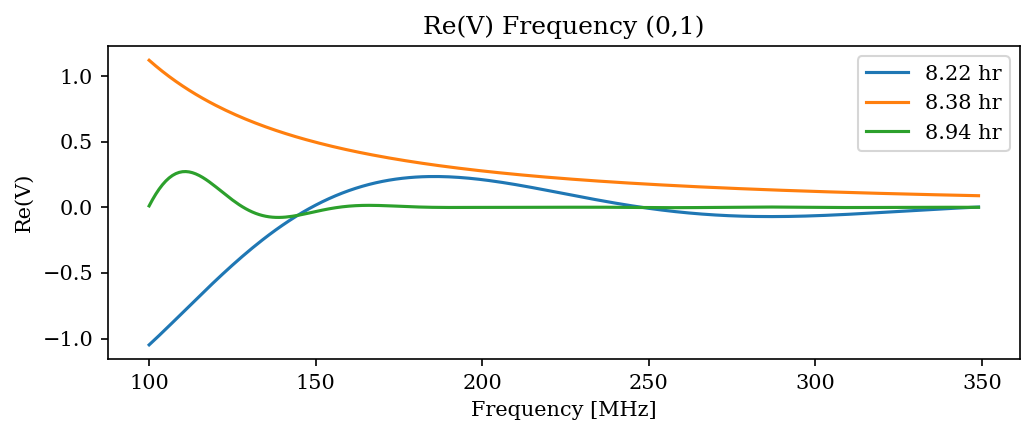

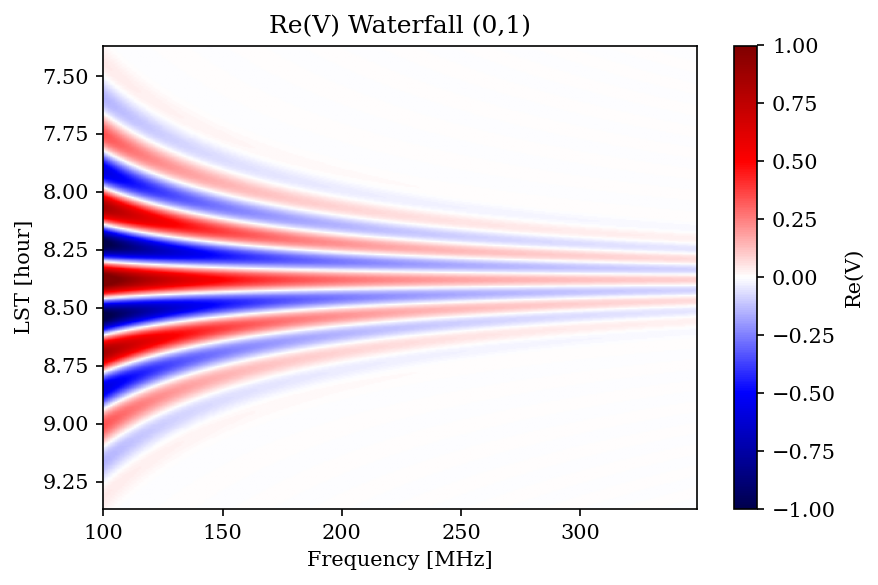

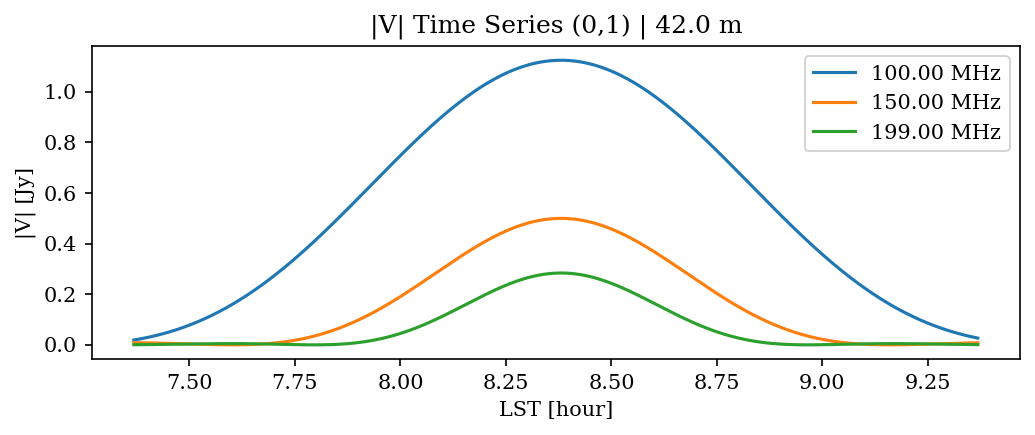

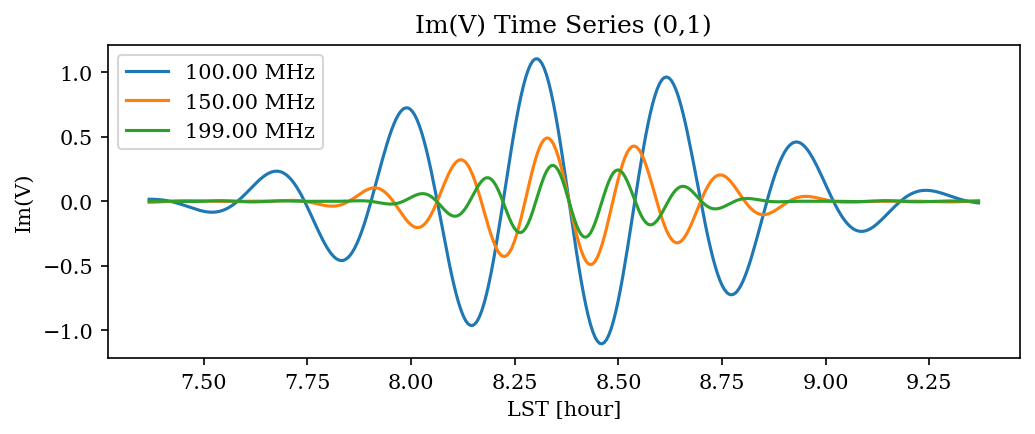

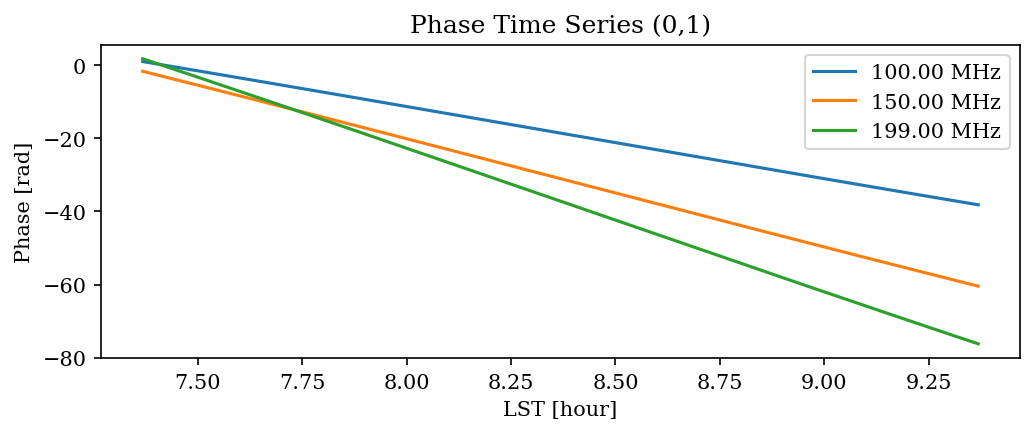

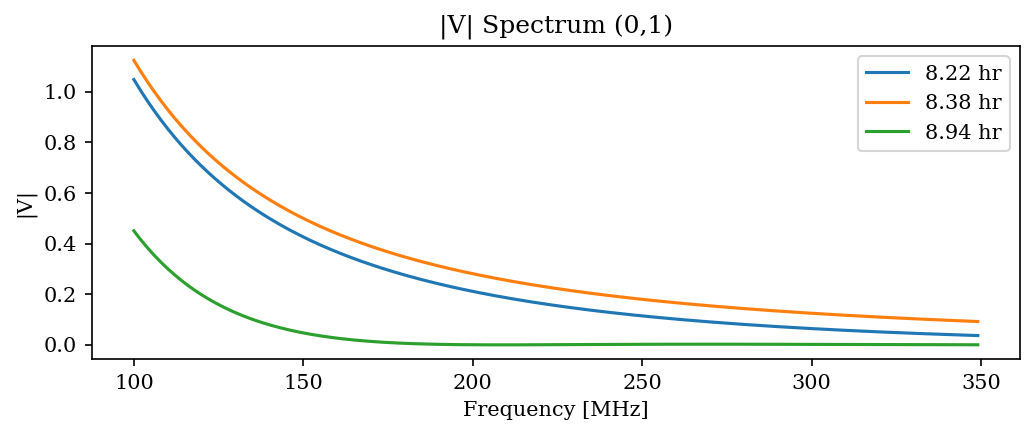

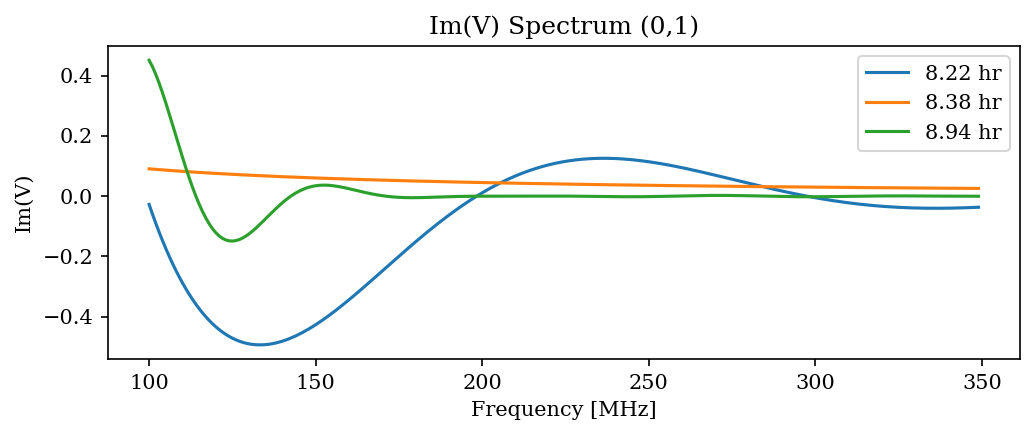

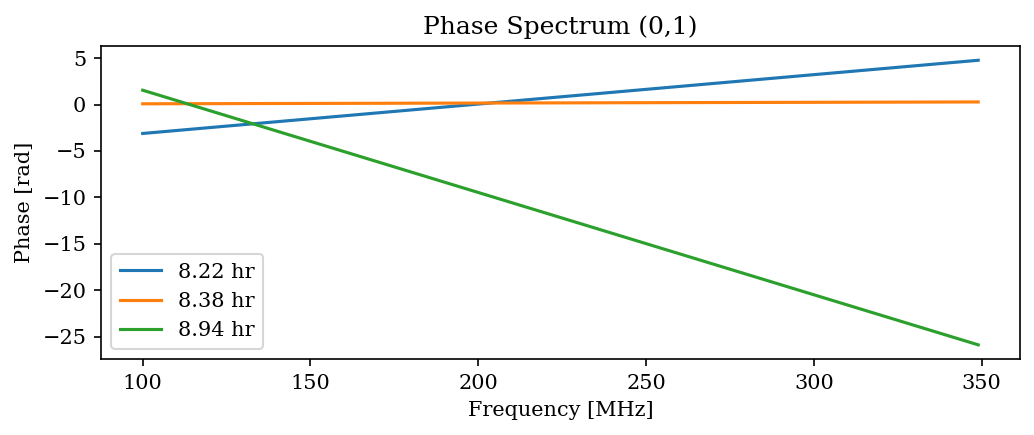

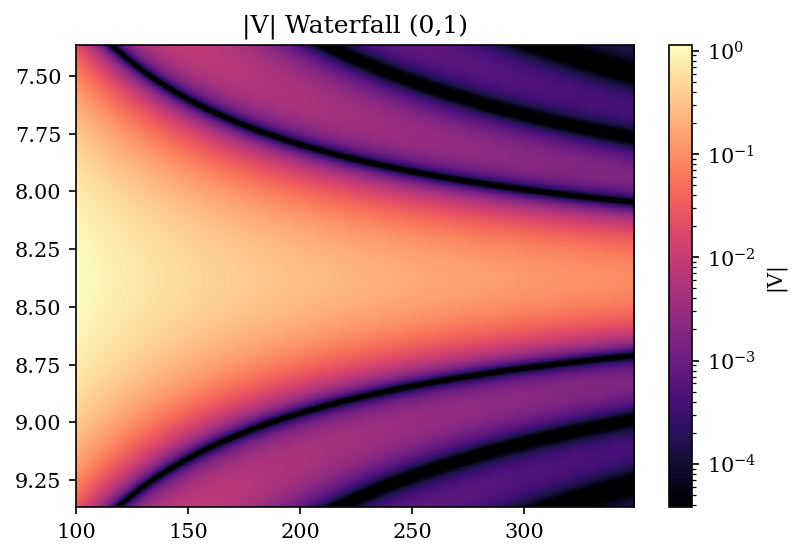

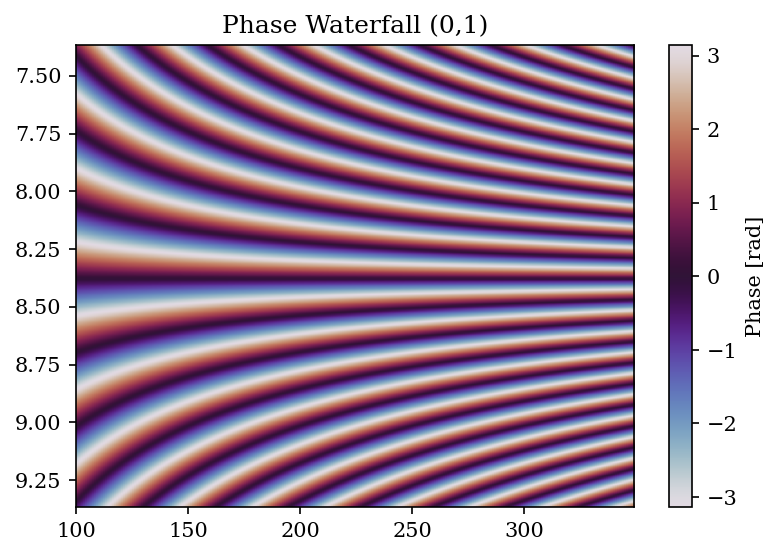

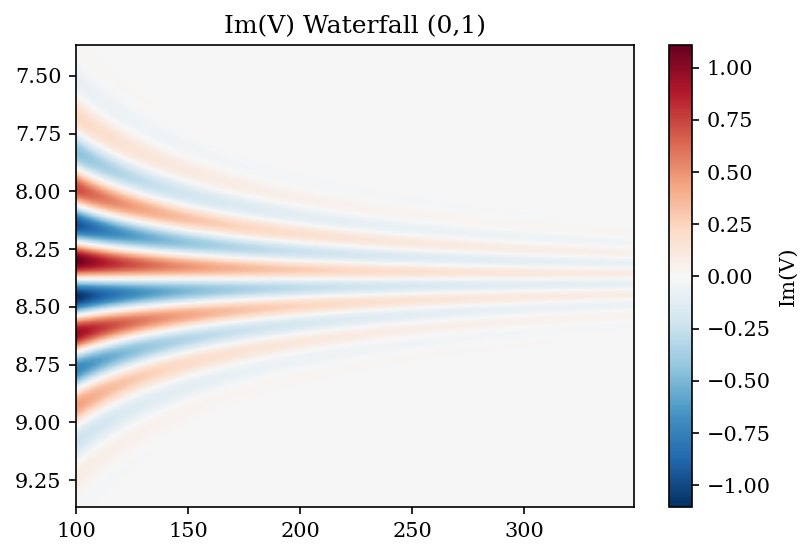


Baseline (0,2) = 42.00 m


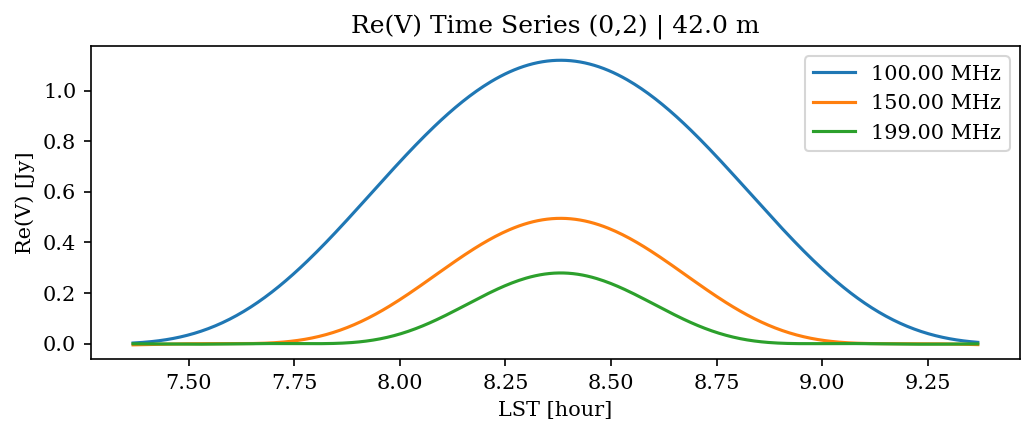

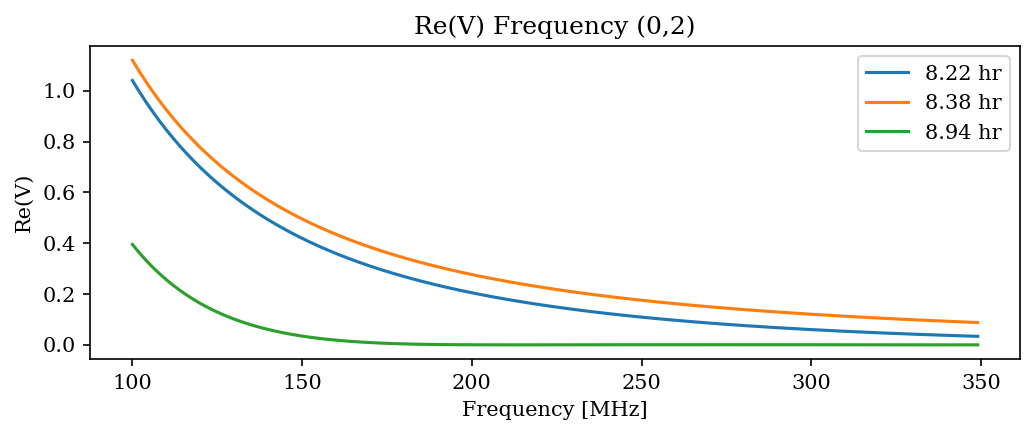

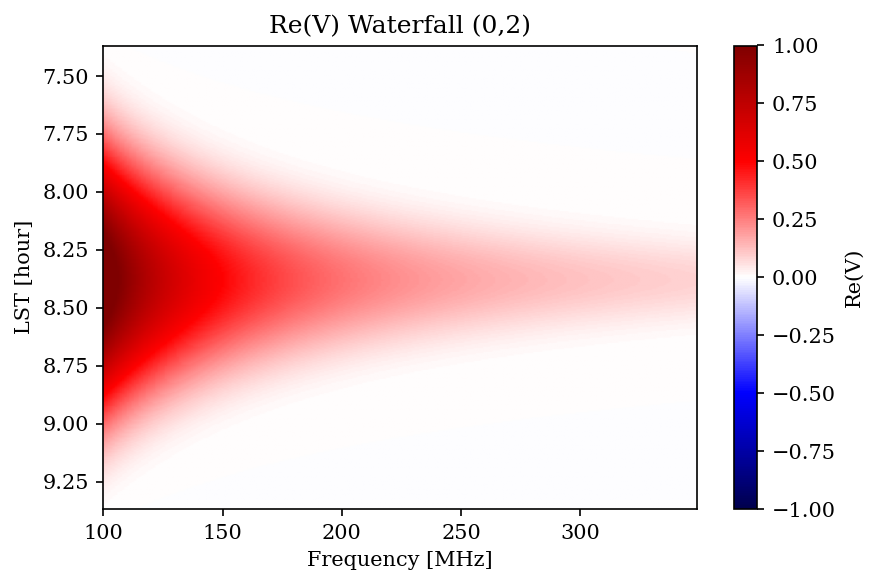

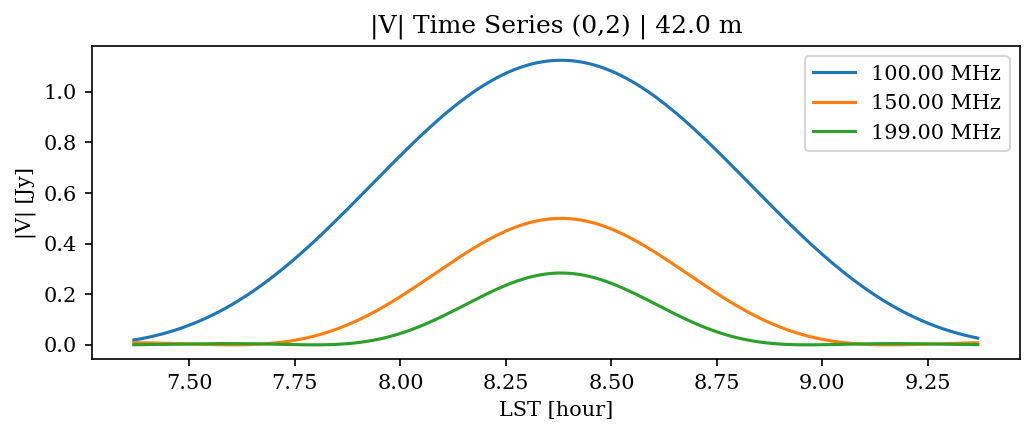

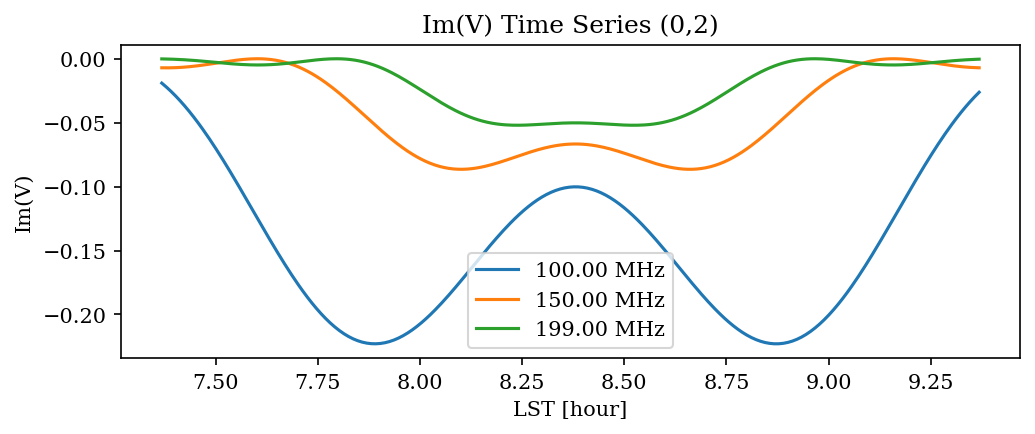

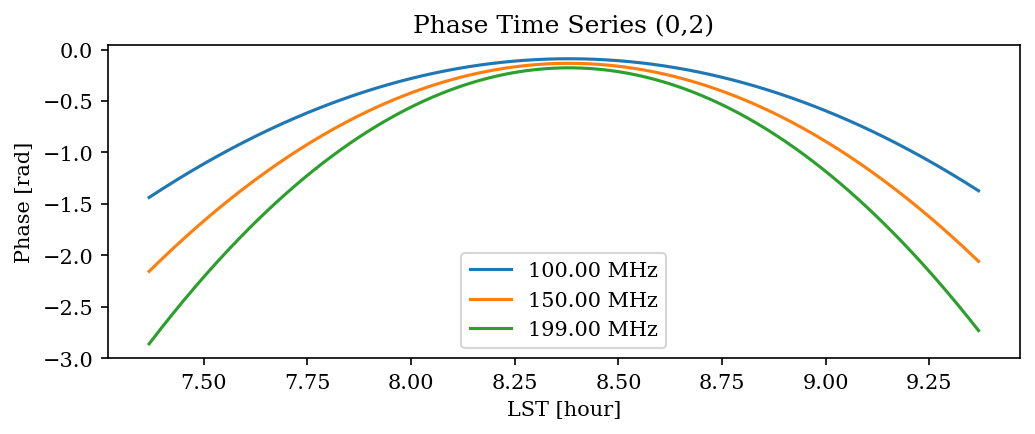

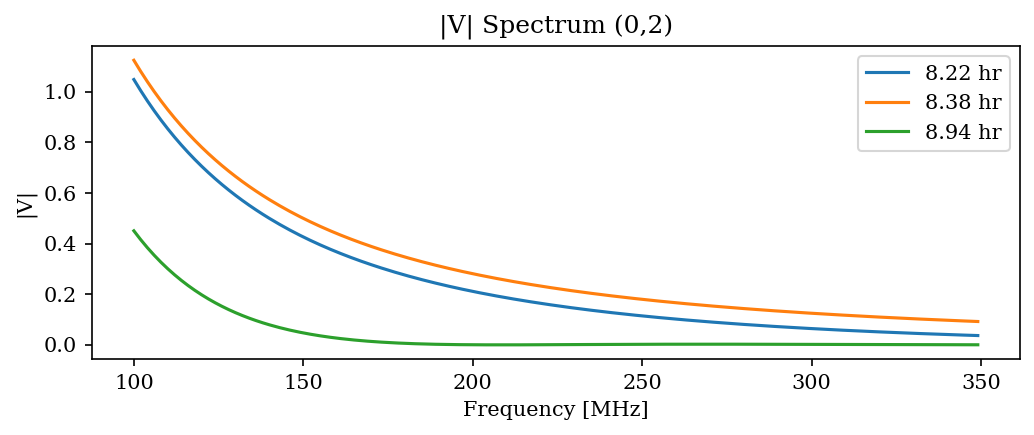

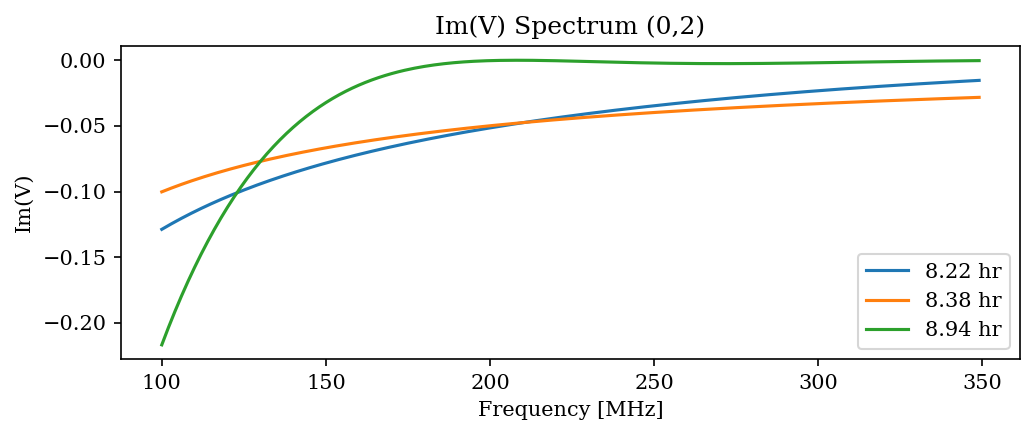

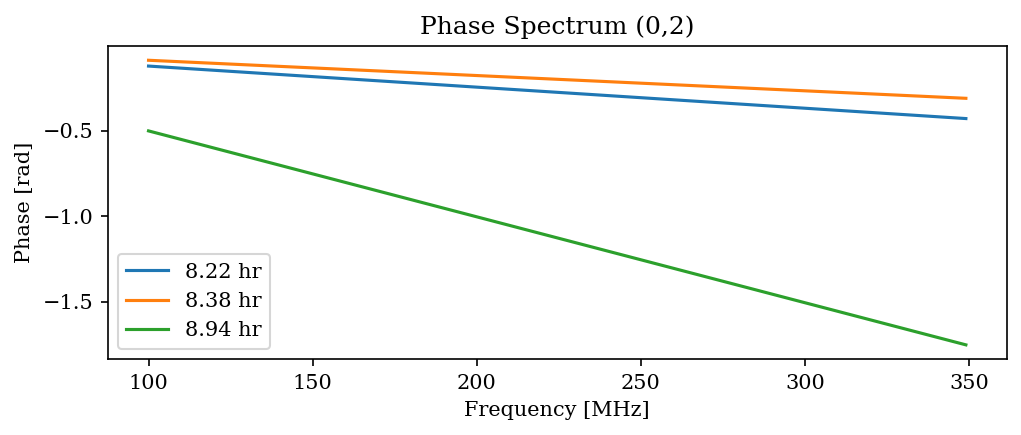

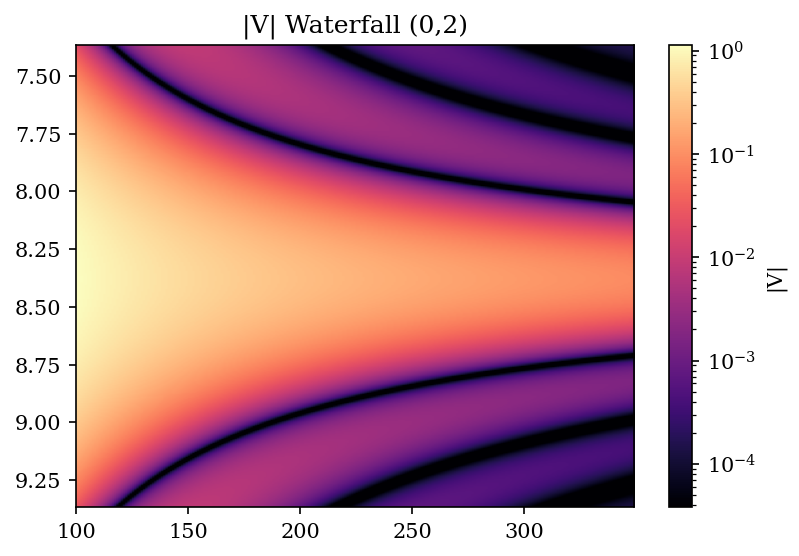

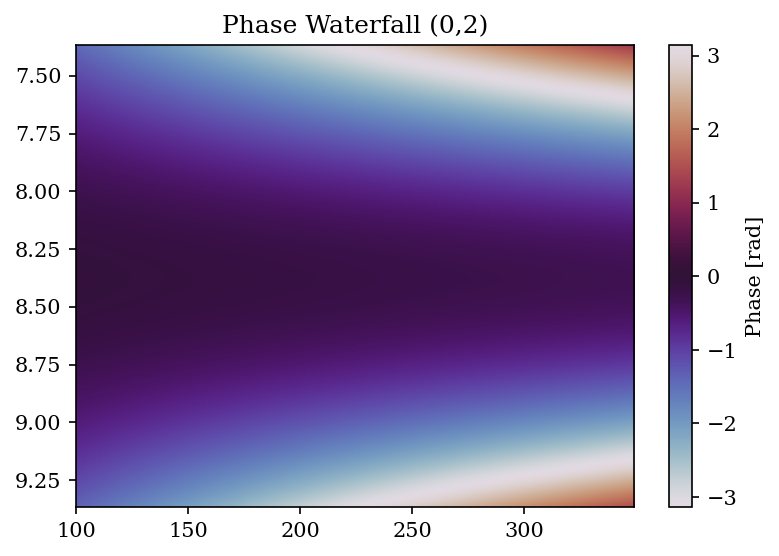

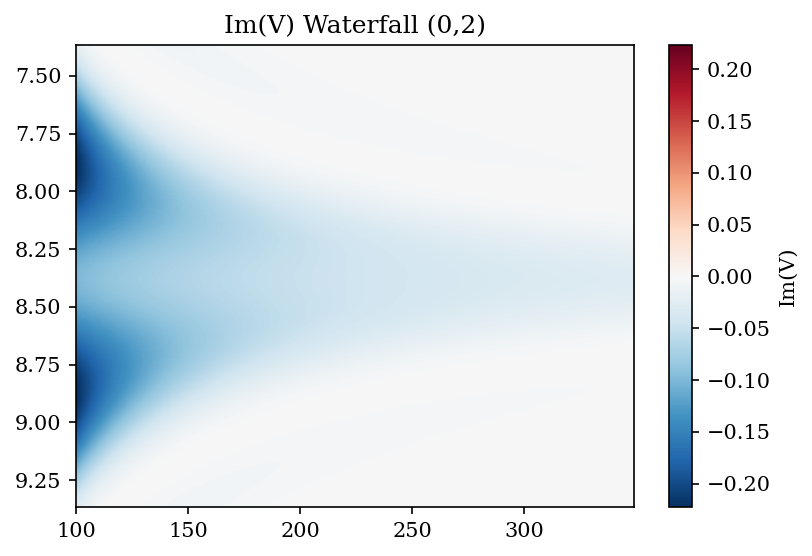


Baseline (0,3) = 59.40 m


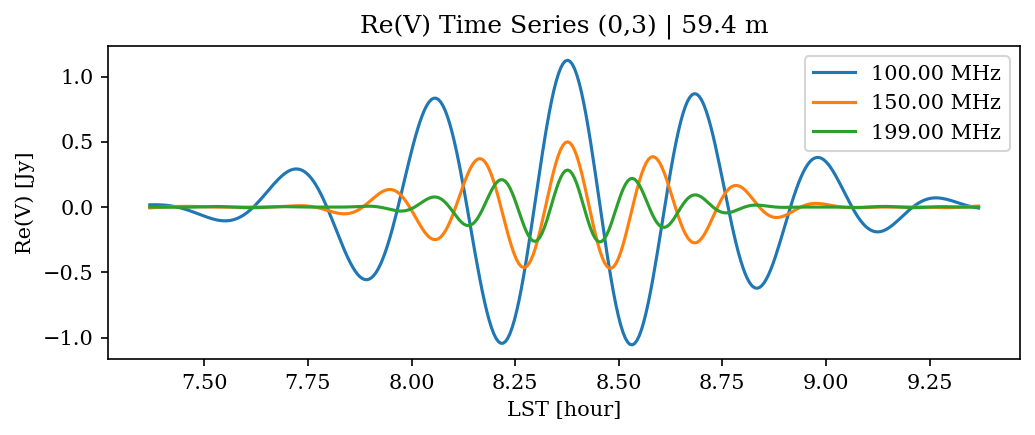

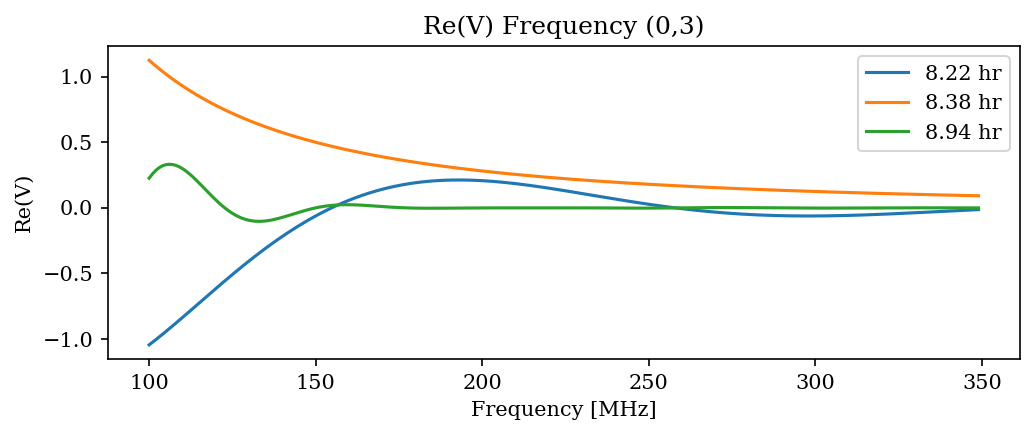

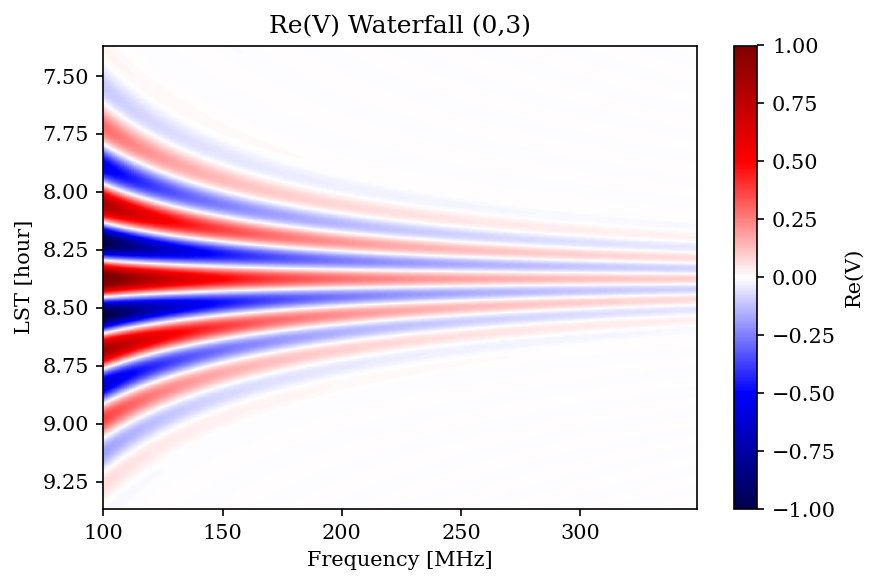

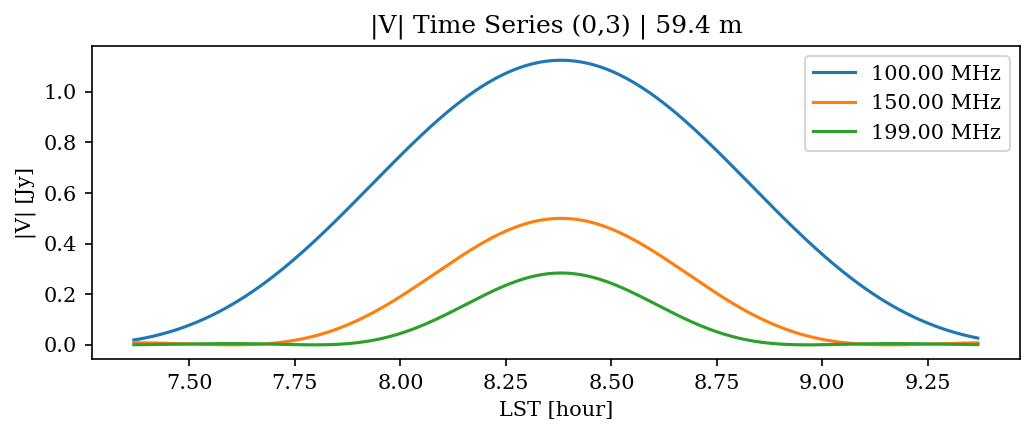

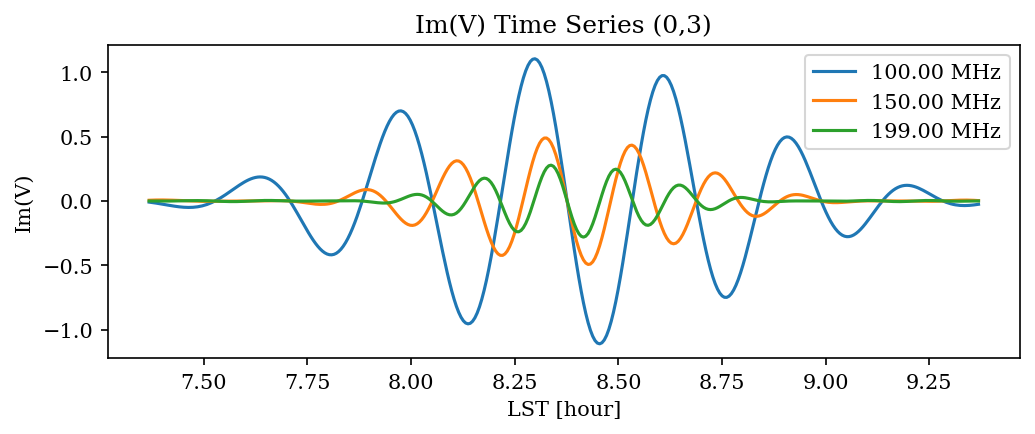

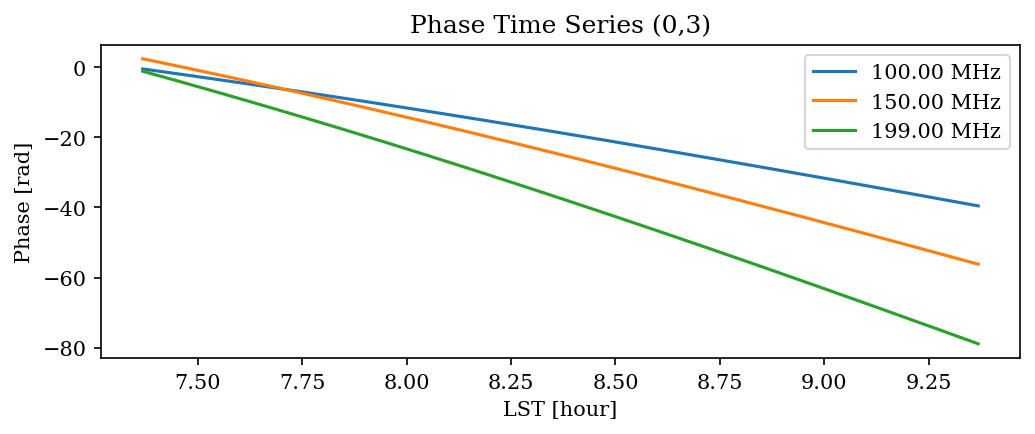

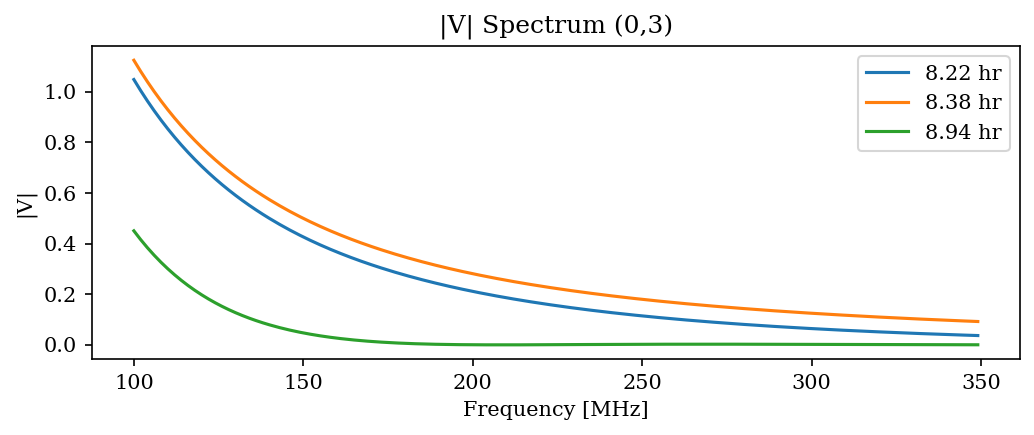

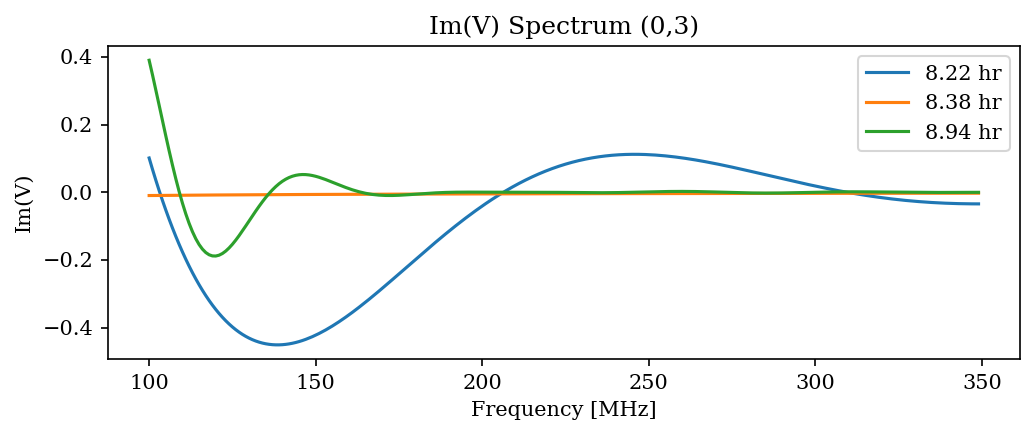

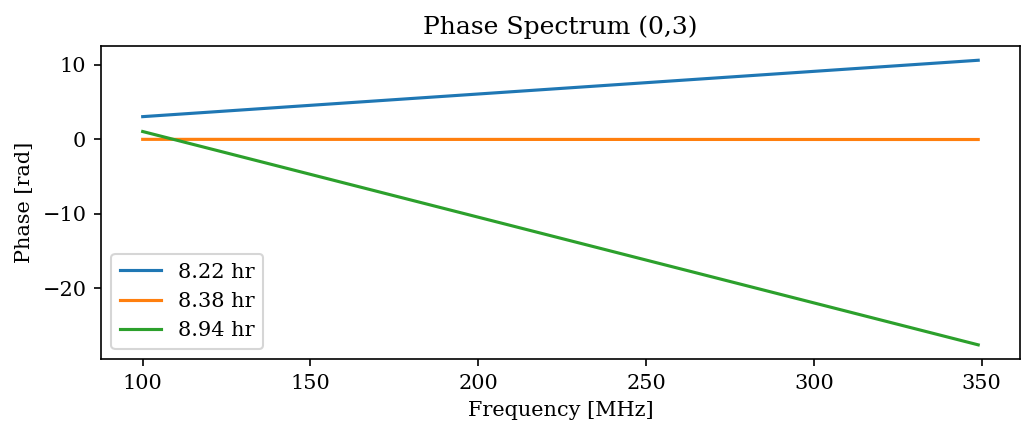

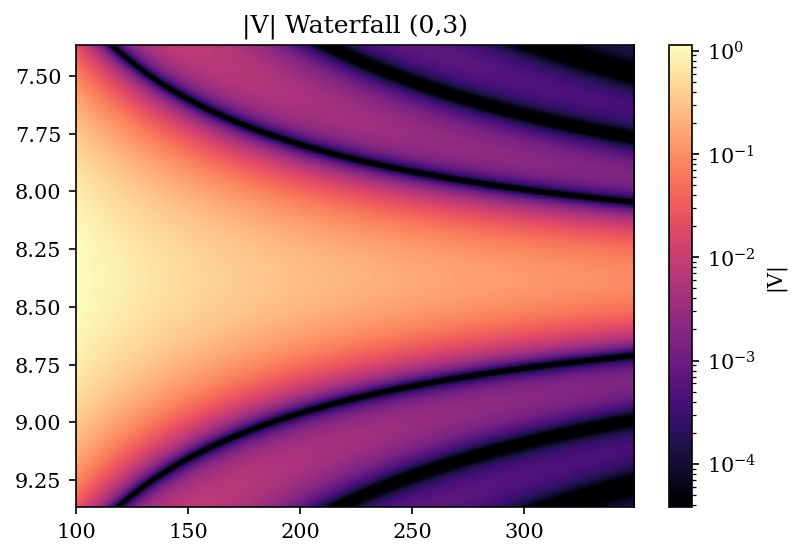

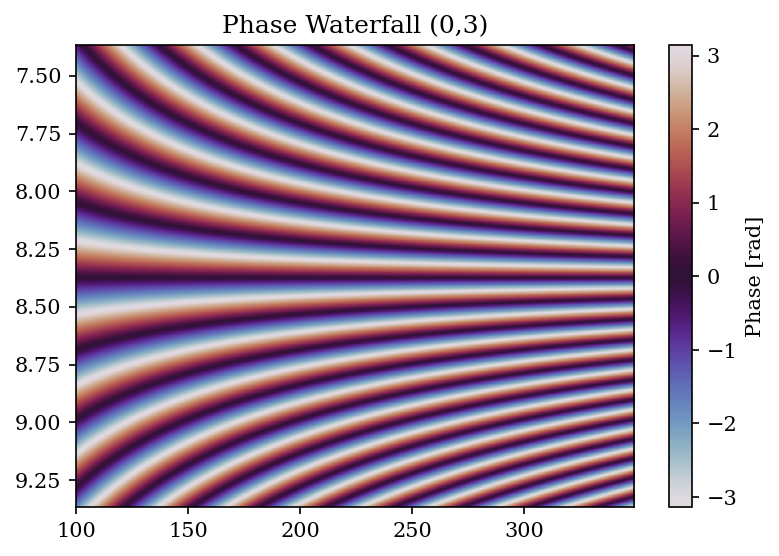

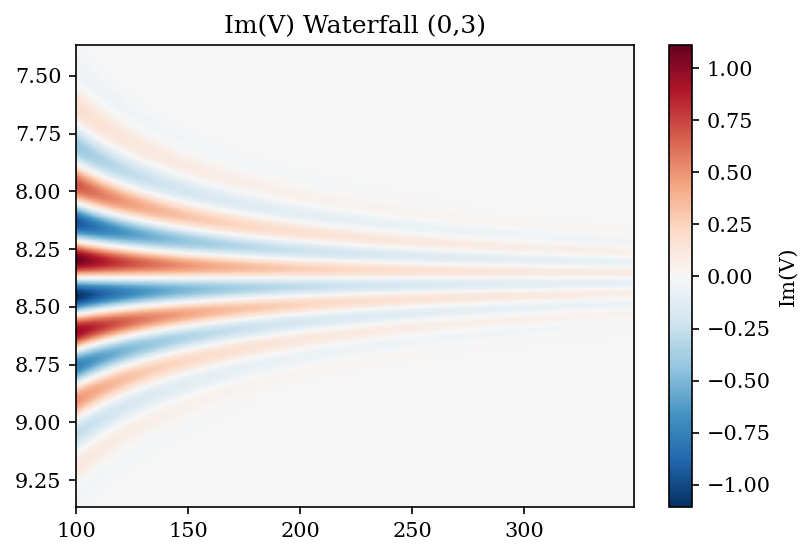


Baseline (1,2) = 59.40 m


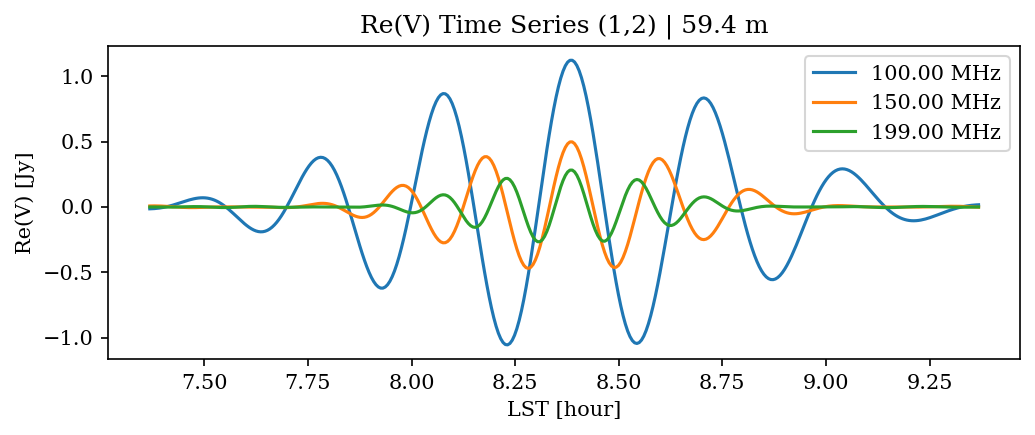

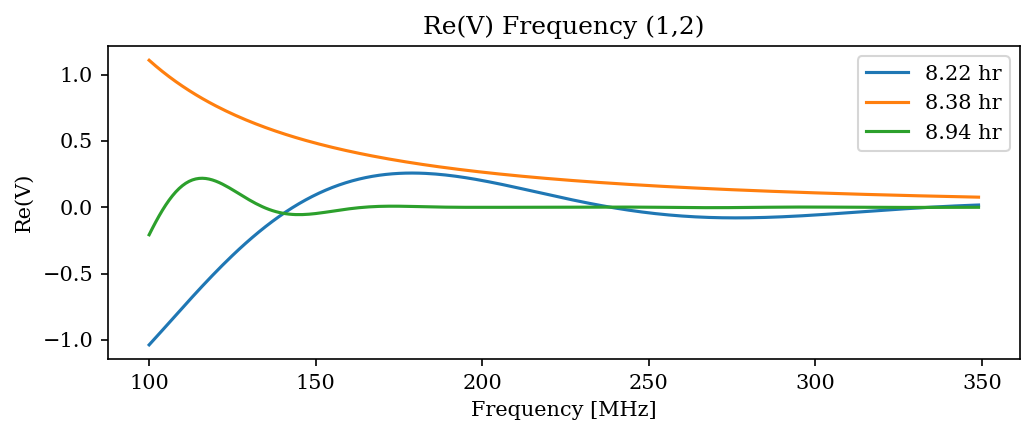

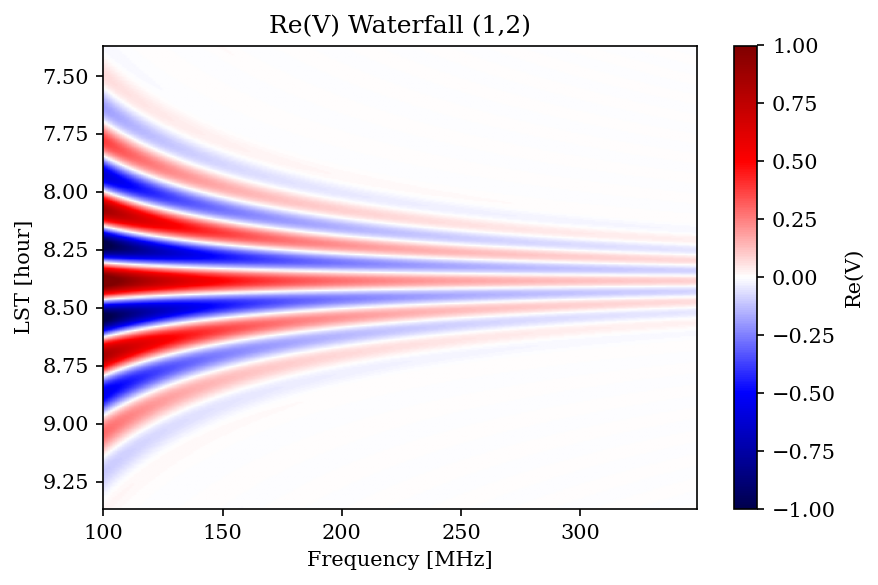


Baseline (1,3) = 42.00 m


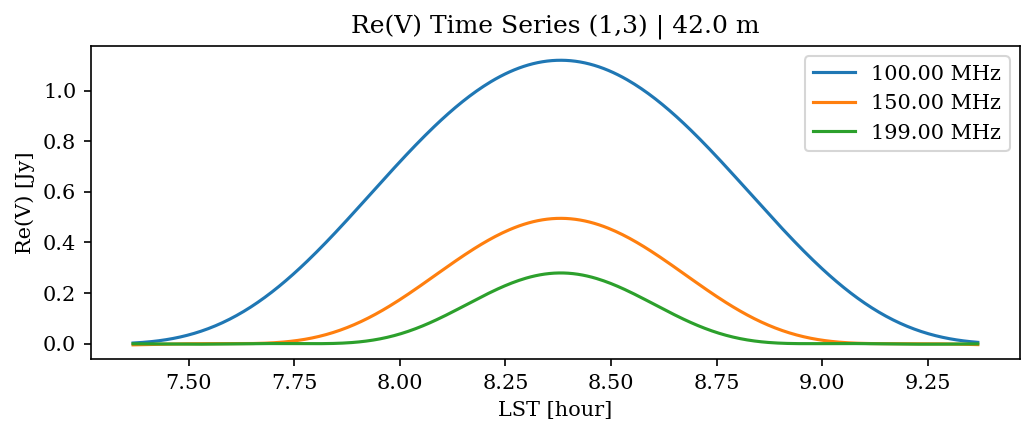

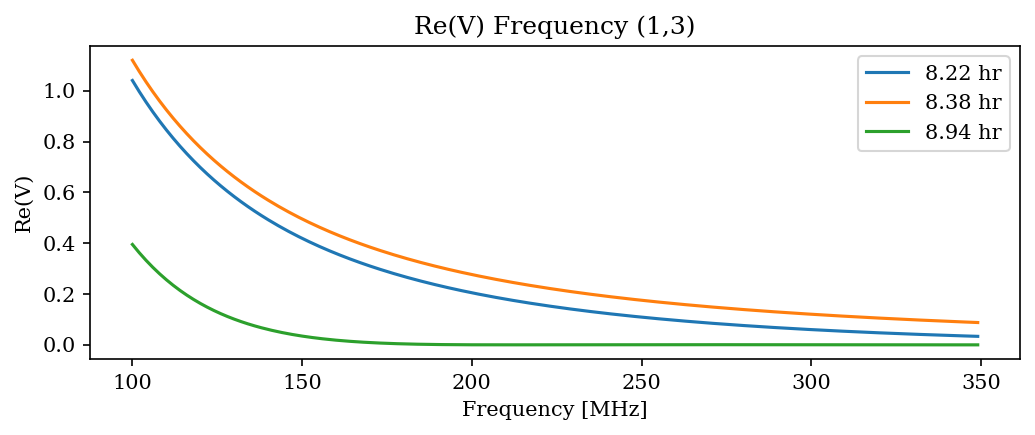

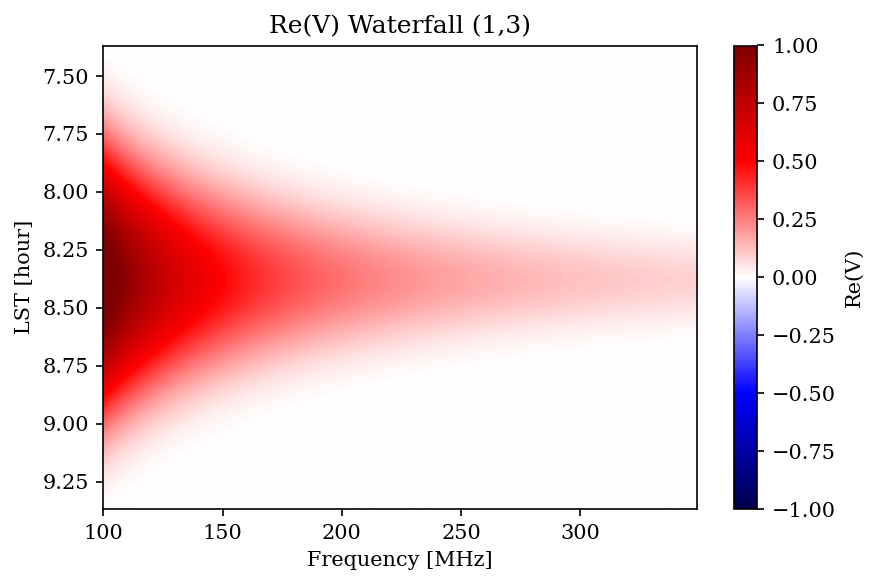


Baseline (2,3) = 42.00 m


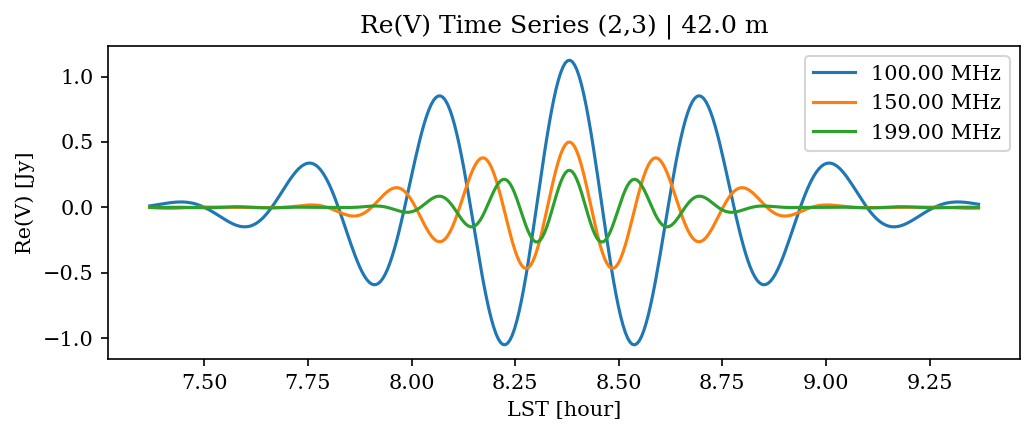

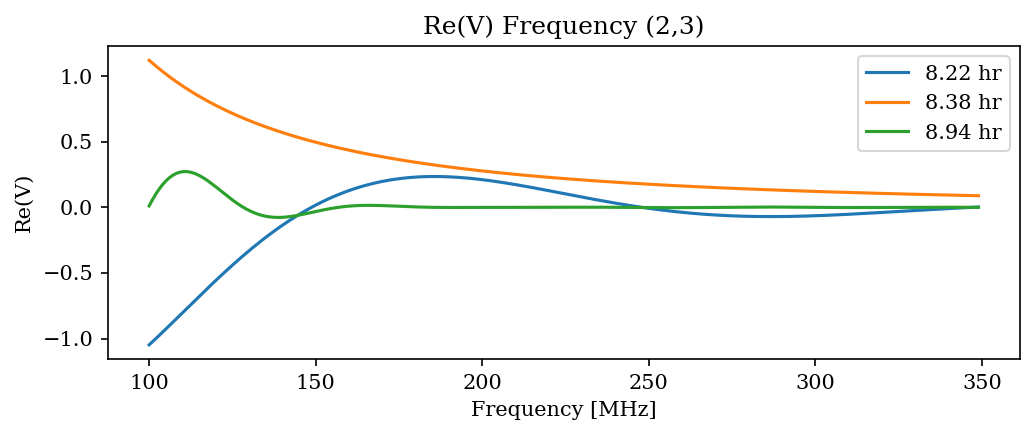

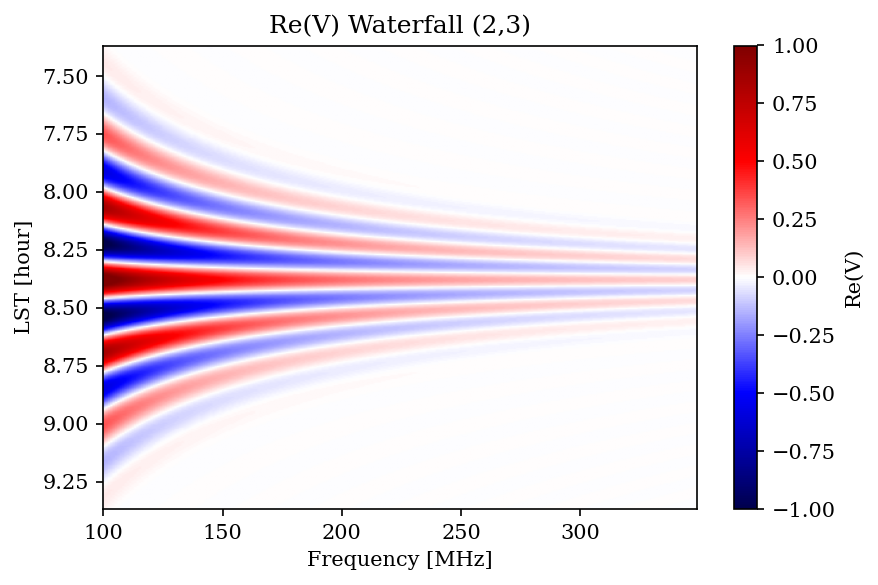

In [39]:
baselines = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]
highlight = [(0,1), (0,2), (0,3)]
for ant1, ant2 in baselines:
    vis = uvdata.get_data(ant1, ant2, "xx")
    # baseline length
    baseline_vec = array_layout[ant2] - array_layout[ant1]
    baseline_length = np.linalg.norm(baseline_vec)
    print(f"\nBaseline ({ant1},{ant2}) = {baseline_length:.2f} m")
    # 1. TIME SERIES (Re)
    plt.figure(figsize=(7,3), dpi=150)
    for chan in (0, 50, 99):
        plt.plot(lsts_hr, vis[:,chan].real, label=f"{freqs_MHz[chan]:.2f} MHz")
    plt.title(f"Re(V) Time Series ({ant1},{ant2}) | {baseline_length:.1f} m")
    plt.xlabel("LST [hour]")
    plt.ylabel("Re(V) [Jy]")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"re_time_{ant1}_{ant2}.pdf")
    plt.show()
    # 2. FREQUENCY (Re)
    plt.figure(figsize=(7,3), dpi=150)
    for t in (153, 181, 282):
        plt.plot(freqs_MHz, vis[t].real, label=f"{lsts_hr[t]:.2f} hr")
    plt.title(f"Re(V) Frequency ({ant1},{ant2})")
    plt.xlabel("Frequency [MHz]")
    plt.ylabel("Re(V)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"re_freq_{ant1}_{ant2}.pdf")
    plt.show()
    # 3. WATERFALL (Re)
    extent = (freqs_MHz[0], freqs_MHz[-1], lsts_hr[-1], lsts_hr[0])
    plt.figure(figsize=(6,4), dpi=150)
    plt.imshow(np.real(vis), extent=extent, aspect='auto',cmap="seismic", vmin=-1, vmax=1)
    plt.title(f"Re(V) Waterfall ({ant1},{ant2})")
    plt.xlabel("Frequency [MHz]")
    plt.ylabel("LST [hour]")
    plt.colorbar(label="Re(V)")
    plt.tight_layout()
    plt.savefig(f"re_waterfall_{ant1}_{ant2}.pdf")
    plt.show()
    if (ant1, ant2) in highlight:
        # Amplitude time series
        plt.figure(figsize=(7,3), dpi=150)
        for chan in (0, 50, 99):
            plt.plot(lsts_hr, np.abs(vis[:,chan]), label=f"{freqs_MHz[chan]:.2f} MHz")
        plt.title(f"|V| Time Series ({ant1},{ant2}) | {baseline_length:.1f} m")
        plt.xlabel("LST [hour]")
        plt.ylabel("|V| [Jy]")
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"amp_time_{ant1}_{ant2}.pdf")
        plt.show()
        # Imaginary time series
        plt.figure(figsize=(7,3), dpi=150)
        for chan in (0, 50, 99):
            plt.plot(lsts_hr, vis[:,chan].imag, label=f"{freqs_MHz[chan]:.2f} MHz")
        plt.title(f"Im(V) Time Series ({ant1},{ant2})")
        plt.xlabel("LST [hour]")
        plt.ylabel("Im(V)")
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"im_time_{ant1}_{ant2}.pdf")
        plt.show()
        # Phase time series
        plt.figure(figsize=(7,3), dpi=150)
        for chan in (0, 50, 99):
            phase = np.unwrap(np.angle(vis[:,chan]))
            plt.plot(lsts_hr, phase, label=f"{freqs_MHz[chan]:.2f} MHz")
        plt.title(f"Phase Time Series ({ant1},{ant2})")
        plt.xlabel("LST [hour]")
        plt.ylabel("Phase [rad]")
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"phase_time_{ant1}_{ant2}.pdf")
        plt.show()
        # amplitude frequency
        plt.figure(figsize=(7,3), dpi=150)
        for t in (153, 181, 282):
            plt.plot(freqs_MHz, np.abs(vis[t]), label=f"{lsts_hr[t]:.2f} hr")
        plt.title(f"|V| Spectrum ({ant1},{ant2})")
        plt.xlabel("Frequency [MHz]")
        plt.ylabel("|V|")
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"amp_freq_{ant1}_{ant2}.pdf")
        plt.show()

        # imaginary frequency
        plt.figure(figsize=(7,3), dpi=150)
        for t in (153, 181, 282):
            plt.plot(freqs_MHz, vis[t].imag, label=f"{lsts_hr[t]:.2f} hr")
        plt.title(f"Im(V) Spectrum ({ant1},{ant2})")
        plt.xlabel("Frequency [MHz]")
        plt.ylabel("Im(V)")
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"im_freq_{ant1}_{ant2}.pdf")
        plt.show()
        # phase frequency
        plt.figure(figsize=(7,3), dpi=150)
        for t in (153, 181, 282):
            plt.plot(freqs_MHz, np.unwrap(np.angle(vis[t])), label=f"{lsts_hr[t]:.2f} hr")
        plt.title(f"Phase Spectrum ({ant1},{ant2})")
        plt.xlabel("Frequency [MHz]")
        plt.ylabel("Phase [rad]")
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"phase_freq_{ant1}_{ant2}.pdf")
        plt.show()

        # amplitude waterfall
        plt.figure(figsize=(6,4), dpi=150)
        plt.imshow(np.abs(vis), aspect="auto", extent=extent,cmap="magma",norm=plt.cm.colors.LogNorm(vmin=np.percentile(np.abs(vis), 5),vmax=np.max(np.abs(vis))))
        plt.title(f"|V| Waterfall ({ant1},{ant2})")
        plt.colorbar(label="|V|")
        plt.savefig(f"amp_waterfall_{ant1}_{ant2}.pdf")
        plt.show()
        # phase waterfall
        plt.figure(figsize=(6,4), dpi=150)
        plt.imshow(np.angle(vis), aspect="auto", extent=extent,cmap="twilight", vmin=-np.pi, vmax=np.pi)
        plt.title(f"Phase Waterfall ({ant1},{ant2})")
        plt.colorbar(label="Phase [rad]")
        plt.savefig(f"phase_waterfall_{ant1}_{ant2}.pdf")
        plt.show()
        # imaginary waterfall
        vmax = np.max(np.abs(np.imag(vis)))
        plt.figure(figsize=(6,4), dpi=150)
        plt.imshow(np.imag(vis), aspect="auto", extent=extent,cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        plt.title(f"Im(V) Waterfall ({ant1},{ant2})")
        plt.colorbar(label="Im(V)")
        plt.savefig(f"im_waterfall_{ant1}_{ant2}.pdf")
        plt.show()